<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/LSTM/%E6%AF%94%E7%89%B9%E5%B8%81%E4%BB%B7%E6%A0%BCLSTM%E6%97%B6%E9%97%B4%E5%BA%8F%E5%88%97%E9%A2%84%E6%B5%8B%E6%95%99%E7%A8%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 比特币价格LSTM时间序列预测教程
## 深度学习(DL)在金融时间序列预测中的应用


### 📈 教程概述

本教程将带您完整学习如何使用LSTM（长短期记忆网络）对比特币价格进行时间序列预测。这是一个专业的金融数据分析项目，结合了深度学习、时间序列分析和金融工程的知识。

### 🎯 学习目标

通过本教程，您将掌握：
1. **时间序列预测理论**：理解时间序列的特性和预测方法
2. **LSTM在时间序列中的应用**：掌握LSTM处理序列数据的原理
3. **金融数据分析技巧**：学习金融时间序列的特殊处理方法
4. **特征工程技术**：构建技术指标和时间特征
5. **模型评估与优化**：全面评估预测模型的性能

### 📊 数据集信息

- **训练数据**: 2013年4月27日 - 2017年7月30日 (1,556天)
- **测试数据**: 2017年8月3日 - 2017年8月7日 (7天)
- **数据特征**: 日期、开盘价、最高价、最低价、收盘价、交易量、市值
- **预测目标**: 比特币收盘价
- **任务类型**: 时间序列回归预测

### 为什么选择LSTM进行时间序列预测？

**传统方法的局限性：**
- ARIMA模型假设数据平稳性，但金融数据通常非平稳
- 线性回归无法捕获复杂的非线性模式
- 传统方法难以处理多变量时间序列

**LSTM的优势：**
1. **长期记忆能力**: 能够记住长期的价格趋势和模式
2. **非线性建模**: 捕获复杂的价格动态关系
3. **多变量处理**: 同时考虑价格、交易量等多个因素
4. **自适应学习**: 能够适应市场环境的变化

### 📉 金融时间序列的特点

1. **非平稳性**: 价格序列通常包含趋势和季节性
2. **波动聚集性**: 高波动期往往聚集在一起
3. **噪声较大**: 受到各种随机因素影响
4. **异方差性**: 方差随时间变化
5. **长期依赖**: 历史价格对未来价格有长期影响


## 1. 环境设置和依赖库导入

首先安装并导入所有必要的库。每个库都有详细的功能说明。

In [59]:
# 设置随机种子，确保结果可重现
import random
import numpy as np
import tensorflow as tf
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 基础数据处理库
import pandas as pd                    # 数据框操作和时间序列处理
import numpy as np                     # 数值计算和数组操作
from datetime import datetime, timedelta  # 日期时间处理
import warnings
warnings.filterwarnings('ignore')      # 忽略警告信息

# 数据可视化库
import matplotlib.pyplot as plt        # 基础绘图
import matplotlib.dates as mdates      # 日期格式化
import seaborn as sns                  # 统计图表

# 高级可视化库
import plotly.graph_objects as go      # 交互式图表
import plotly.express as px           # 快速图表
from plotly.subplots import make_subplots  # 子图布局

# 机器学习库
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # 数据标准化
from sklearn.metrics import (          # 评估指标
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# 深度学习框架 - TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model          # 模型构建
from tensorflow.keras.layers import (                          # 网络层
    LSTM,
    Dense,
    Dropout,
    Input,
    Bidirectional,
    GRU
)
from tensorflow.keras.optimizers import Adam, RMSprop          # 优化器
from tensorflow.keras.callbacks import (                       # 回调函数
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    TensorBoard
)
from tensorflow.keras.regularizers import l1, l2              # 正则化

# 时间序列分析库
from scipy import stats               # 统计分析
from scipy.stats import jarque_bera   # 正态性检验

# 技术分析库（如果需要安装：pip install ta-lib）
try:
    import talib
    TALIB_AVAILABLE = True
    print("✅ TA-Lib 可用")
except ImportError:
    TALIB_AVAILABLE = False
    print("⚠️ TA-Lib 未安装，将使用自定义技术指标")

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置图表样式
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 检查GPU可用性
print(f"\n🔧 系统环境信息:")
print(f"TensorFlow版本: {tf.__version__}")
print(f"Python版本: {sys.version.split()[0] if 'sys' in locals() else 'Unknown'}")
print(f"GPU可用: {len(tf.config.list_physical_devices('GPU')) > 0}")
if len(tf.config.list_physical_devices('GPU')) > 0:
    print(f"GPU设备: {tf.config.list_physical_devices('GPU')}")

print("\n✅ 所有库导入成功！")

⚠️ TA-Lib 未安装，将使用自定义技术指标

🔧 系统环境信息:
TensorFlow版本: 2.19.0
Python版本: Unknown
GPU可用: False

✅ 所有库导入成功！


## 2. 数据加载和初步分析

加载比特币历史价格数据并进行初步的探索性数据分析。

### 2.1 数据加载

In [60]:
# 数据文件路径
TRAIN_DATA_PATH = '/content/drive/MyDrive/AI_Lecture/ML_DL/LSTM/bitcoin_price_Training - Training.csv'
TEST_DATA_PATH = '/content/drive/MyDrive/AI_Lecture/ML_DL/LSTM/bitcoin_price_1week_Test - Test.csv'

# 检查文件是否存在
def check_file_exists(file_path, file_type):
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"✅ {file_type}文件找到: {file_path}")
        print(f"   文件大小: {file_size:.1f} KB")
        return True
    else:
        print(f"❌ 错误：找不到{file_type}文件 {file_path}")
        return False

train_file_exists = check_file_exists(TRAIN_DATA_PATH, "训练")
test_file_exists = check_file_exists(TEST_DATA_PATH, "测试")

if not (train_file_exists and test_file_exists):
    raise FileNotFoundError("请确保数据文件路径正确")

✅ 训练文件找到: /content/drive/MyDrive/AI_Lecture/ML_DL/LSTM/bitcoin_price_Training - Training.csv
   文件大小: 108.6 KB
✅ 测试文件找到: /content/drive/MyDrive/AI_Lecture/ML_DL/LSTM/bitcoin_price_1week_Test - Test.csv
   文件大小: 0.6 KB


In [61]:
# 加载训练数据
print("📊 正在加载训练数据...")
try:
    # 尝试不同的编码格式
    for encoding in ['utf-8', 'latin1', 'cp1252']:
        try:
            train_df = pd.read_csv(TRAIN_DATA_PATH, encoding=encoding)
            print(f"✅ 训练数据加载成功（编码: {encoding}）")
            break
        except UnicodeDecodeError:
            continue
    else:
        raise ValueError("无法读取训练数据文件")

    # 加载测试数据
    for encoding in ['utf-8', 'latin1', 'cp1252']:
        try:
            test_df = pd.read_csv(TEST_DATA_PATH, encoding=encoding)
            print(f"✅ 测试数据加载成功（编码: {encoding}）")
            break
        except UnicodeDecodeError:
            continue
    else:
        raise ValueError("无法读取测试数据文件")

except Exception as e:
    print(f"❌ 数据加载失败: {e}")
    raise

# 显示基本信息
print(f"\n📋 数据集基本信息:")
print(f"训练数据形状: {train_df.shape}")
print(f"测试数据形状: {test_df.shape}")
print(f"\n训练数据列名: {list(train_df.columns)}")
print(f"测试数据列名: {list(test_df.columns)}")

📊 正在加载训练数据...
✅ 训练数据加载成功（编码: utf-8）
✅ 测试数据加载成功（编码: utf-8）

📋 数据集基本信息:
训练数据形状: (1556, 7)
测试数据形状: (7, 7)

训练数据列名: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap']
测试数据列名: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap']


In [62]:
# 查看数据样例
print("👀 训练数据前5行:")
display(train_df.head())

👀 训练数据前5行:


,Date,Open,High,Low,Close,Volume,Market Cap
0,"Jul 31, 2017",2763.24,2889.62,2720.61,2875.34,"860,575,000","45,535,800,000"
1,"Jul 30, 2017",2724.39,2758.53,2644.85,2757.18,"705,943,000","44,890,700,000"
2,"Jul 29, 2017",2807.02,2808.76,2692.80,2726.45,"803,746,000","46,246,700,000"
3,"Jul 28, 2017",2679.73,2897.45,2679.73,2809.01,"1,380,100,000","44,144,400,000"
4,"Jul 27, 2017",2538.71,2693.32,2529.34,2671.78,"789,104,000","41,816,500,000"


In [63]:
print("\n👀 测试数据前5行:")
display(test_df.head())


👀 测试数据前5行:


,Date,Open,High,Low,Close,Volume,Market Cap
0,"Aug 07, 2017",3212.78,3397.68,3180.89,3378.94,"1,482,280,000","52,987,300,000"
1,"Aug 06, 2017",3257.61,3293.29,3155.60,3213.94,"1,105,030,000","53,720,900,000"
2,"Aug 05, 2017",2897.63,3290.01,2874.83,3252.91,"1,945,700,000","47,778,200,000"
3,"Aug 04, 2017",2806.93,2899.33,2743.72,2895.89,"1,002,120,000","46,276,200,000"
4,"Aug 03, 2017",2709.56,2813.31,2685.14,2804.73,"804,797,000","44,666,400,000"


In [64]:
# 数据类型检查
print(f"\n🔍 训练数据类型:")
print(train_df.dtypes)


🔍 训练数据类型:
Date           object
Open          float64
High          float64
Low           float64
Close         float64
Volume         object
Market Cap     object
dtype: object


In [65]:
print(f"\n🔍 测试数据类型:")
print(test_df.dtypes)


🔍 测试数据类型:
Date           object
Open          float64
High          float64
Low           float64
Close         float64
Volume         object
Market Cap     object
dtype: object


### 2.2 日期处理和数据清洗

In [66]:
def process_dataframe(df, data_type="训练"):
    """
    处理数据框：日期解析、数据清洗、类型转换

    参数:
        df: 原始数据框
        data_type: 数据类型（用于日志显示）

    返回:
        处理后的数据框
    """
    print(f"\n🔧 正在处理{data_type}数据...")

    # 创建副本避免修改原数据
    df_processed = df.copy()

    # 日期列处理
    if 'Date' in df_processed.columns:
        # 尝试不同的日期格式
        try:
            df_processed['Date'] = pd.to_datetime(df_processed['Date'])
            print(f"✅ 日期解析成功")
        except:
            try:
                df_processed['Date'] = pd.to_datetime(df_processed['Date'], format='%Y-%m-%d')
                print(f"✅ 日期解析成功（指定格式）")
            except Exception as e:
                print(f"⚠️ 日期解析出现问题: {e}")

    # 设置日期为索引
    if 'Date' in df_processed.columns:
        df_processed.set_index('Date', inplace=True)
        print(f"✅ 日期索引设置完成")

    # 数值列处理
    numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap']

    for col in numeric_columns:
        if col in df_processed.columns:
            # 处理可能的字符串格式（如包含逗号）
            if df_processed[col].dtype == 'object':
                df_processed[col] = df_processed[col].astype(str).str.replace(',', '')
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

            # 检查负值（价格不应该为负）
            if col in ['Open', 'High', 'Low', 'Close'] and (df_processed[col] < 0).any():
                print(f"⚠️ 发现{col}列有负值，将进行处理")
                df_processed[col] = df_processed[col].abs()

    # Check and handle missing values
    missing_counts = df_processed.isnull().sum()
    if missing_counts.sum() > 0:
        print(f"\n⚠️ 发现缺失值:")
        for col, count in missing_counts[missing_counts > 0].items():
            print(f"   {col}: {count} 个缺失值")

        # For training data, we might drop or fill later. For test data, we should fill.
        # Let's fill for now, and handle dropping when creating sequences.
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)  # Handle leading NaNs
        print(f"✅ 缺失值处理完成")
    else:
        print(f"✅ 无缺失值")


    # 数据合理性检查
    if all(col in df_processed.columns for col in ['Open', 'High', 'Low', 'Close']):
        # Check High >= Low, High >= Open, High >= Close, Low <= Open, Low <= Close
        anomaly_count = 0

        # High应该是最高价
        anomaly_count += (df_processed['High'] < df_processed['Low']).sum()
        anomaly_count += (df_processed['High'] < df_processed['Open']).sum()
        anomaly_count += (df_processed['High'] < df_processed['Close']).sum()

        # Low应该是最低价
        anomaly_count += (df_processed['Low'] > df_processed['Open']).sum()
        anomaly_count += (df_processed['Low'] > df_processed['Close']).sum()

        if anomaly_count > 0:
            print(f"⚠️ 发现{anomaly_count}个价格异常数据点")
        else:
            print(f"✅ 价格数据合理性检查通过")

    # 按日期排序
    df_processed.sort_index(inplace=True)

    print(f"✅ {data_type}数据处理完成")
    print(f"   处理后形状: {df_processed.shape}")
    print(f"   日期范围: {df_processed.index.min()} 到 {df_processed.index.max()}")

    return df_processed

# 处理训练和测试数据
train_data = process_dataframe(train_df, "训练")
test_data = process_dataframe(test_df, "测试")


🔧 正在处理训练数据...
✅ 日期解析成功
✅ 日期索引设置完成

⚠️ 发现缺失值:
   Volume: 243 个缺失值
✅ 缺失值处理完成
✅ 价格数据合理性检查通过
✅ 训练数据处理完成
   处理后形状: (1556, 6)
   日期范围: 2013-04-28 00:00:00 到 2017-07-31 00:00:00

🔧 正在处理测试数据...
✅ 日期解析成功
✅ 日期索引设置完成
✅ 无缺失值
✅ 价格数据合理性检查通过
✅ 测试数据处理完成
   处理后形状: (7, 6)
   日期范围: 2017-08-01 00:00:00 到 2017-08-07 00:00:00


In [67]:
train_data.head()

,Open,High,Low,Close,Volume,Market Cap
Date,,,,,,
2013-04-28,135.30,135.98,132.10,134.21,46862700.0,1500520000
2013-04-29,134.44,147.49,134.00,144.54,46862700.0,1491160000
2013-04-30,144.00,146.93,134.05,139.00,46862700.0,1597780000
2013-05-01,139.00,139.89,107.72,116.99,46862700.0,1542820000
2013-05-02,116.38,125.60,92.28,105.21,46862700.0,1292190000


In [68]:
test_data.head()

,Open,High,Low,Close,Volume,Market Cap
Date,,,,,,
2017-08-01,2871.30,2921.35,2685.61,2718.26,1324670000,47321800000
2017-08-02,2727.13,2762.53,2668.59,2710.67,1094950000,44950800000
2017-08-03,2709.56,2813.31,2685.14,2804.73,804797000,44666400000
2017-08-04,2806.93,2899.33,2743.72,2895.89,1002120000,46276200000
2017-08-05,2897.63,3290.01,2874.83,3252.91,1945700000,47778200000


### 2.3 探索性数据分析 (EDA)

In [69]:
# 基本统计信息
print("📊 训练数据基本统计信息:")
display(train_data.describe())

📊 训练数据基本统计信息:


,Open,High,Low,Close,Volume,Market Cap
count,1556.000000,1556.000000,1556.000000,1556.000000,1.556000e+03,1.556000e+03
mean,582.625328,597.992847,567.851446,584.239396,1.323440e+08,8.694353e+09
std,523.137312,542.992855,505.877401,525.904442,3.001466e+08,8.707288e+09
min,68.500000,74.560000,65.530000,68.430000,2.857830e+06,7.792550e+08
25%,254.287500,260.327500,248.835000,254.320000,2.322780e+07,3.598355e+09
50%,438.600000,447.560000,430.570000,438.855000,4.686270e+07,6.386210e+09
75%,662.437500,674.525000,646.735000,663.402500,7.767028e+07,9.898830e+09
max,2953.220000,2999.910000,2840.530000,2958.110000,2.569530e+09,4.839120e+10


In [70]:
print("\n📊 测试数据基本统计信息:")
display(test_data.describe())


📊 测试数据基本统计信息:


,Open,High,Low,Close,Volume,Market Cap
count,7.000000,7.000000,7.000000,7.000000,7.000000e+00,7.000000e+00
mean,2926.134286,3053.928571,2856.340000,2996.477143,1.251364e+09,4.824309e+10
std,222.327835,263.148120,224.210701,278.478301,3.759925e+08,3.676034e+09
min,2709.560000,2762.530000,2668.590000,2710.670000,8.047970e+08,4.466640e+10
25%,2767.030000,2856.320000,2685.375000,2761.495000,1.048535e+09,4.561350e+10
50%,2871.300000,2921.350000,2743.720000,2895.890000,1.105030e+09,4.732180e+10
75%,3055.205000,3291.650000,3015.215000,3233.425000,1.403475e+09,5.038275e+10
max,3257.610000,3397.680000,3180.890000,3378.940000,1.945700e+09,5.372090e+10


In [71]:
# 价格范围分析
print(f"\n💰 价格范围分析:")
print("训练期间:")
print(f"  最低收盘价: ${train_data['Close'].min():.2f}")
print(f"  最高收盘价: ${train_data['Close'].max():.2f}")
print(f"  价格涨幅: {((train_data['Close'].max() - train_data['Close'].min()) / train_data['Close'].min() * 100):.1f}%")



💰 价格范围分析:
训练期间:
  最低收盘价: $68.43
  最高收盘价: $2958.11
  价格涨幅: 4222.8%


In [72]:
print("\n测试期间:")
print(f"  最低收盘价: ${test_data['Close'].min():.2f}")
print(f"  最高收盘价: ${test_data['Close'].max():.2f}")
print(f"  期间变化: {((test_data['Close'].iloc[-1] - test_data['Close'].iloc[0]) / test_data['Close'].iloc[0] * 100):.1f}%")


测试期间:
  最低收盘价: $2710.67
  最高收盘价: $3378.94
  期间变化: 24.3%


In [73]:
# 计算日收益率
train_data['Returns'] = train_data['Close'].pct_change()
test_data['Returns'] = test_data['Close'].pct_change()

# 收益率统计
print(f"\n📈 收益率分析:")
print(f"平均日收益率: {train_data['Returns'].mean():.4f} ({train_data['Returns'].mean()*100:.2f}%)")
print(f"收益率标准差: {train_data['Returns'].std():.4f} ({train_data['Returns'].std()*100:.2f}%)")
print(f"最大单日涨幅: {train_data['Returns'].max():.4f} ({train_data['Returns'].max()*100:.1f}%)")
print(f"最大单日跌幅: {train_data['Returns'].min():.4f} ({train_data['Returns'].min()*100:.1f}%)")


📈 收益率分析:
平均日收益率: 0.0029 (0.29%)
收益率标准差: 0.0427 (4.27%)
最大单日涨幅: 0.4297 (43.0%)
最大单日跌幅: -0.2337 (-23.4%)


In [74]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 假设你已有 train_data 和 test_data 的 DataFrame
# train_data 和 test_data 至少包含：['Close', 'Volume', 'Returns']

# 创建子图布局
fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=(
        '比特币历史价格走势',
        '交易量分析',
        '日收益率分布',
        '价格波动性分析'
    ),
    vertical_spacing=0.08,
    specs=[[{"secondary_y": False}],
           [{"secondary_y": False}],
           [{"secondary_y": False}],
           [{"secondary_y": False}]]
)

# 1. 价格走势图
fig.add_trace(
    go.Scatter(
        x=train_data.index,
        y=train_data['Close'],
        mode='lines',
        name='训练期收盘价',
        line=dict(color='blue', width=1.5)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=test_data.index,
        y=test_data['Close'],
        mode='lines+markers',
        name='测试期收盘价',
        line=dict(color='red', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

# 2. 交易量分析
fig.add_trace(
    go.Bar(
        x=train_data.index,
        y=train_data['Volume'],
        name='交易量',
        marker_color='lightblue',
        opacity=0.7
    ),
    row=2, col=1
)

# 3. 收益率分布
fig.add_trace(
    go.Histogram(
        x=train_data['Returns'].dropna(),
        nbinsx=50,
        name='收益率分布',
        marker_color='green',
        opacity=0.7
    ),
    row=3, col=1
)

# 4. 30日滚动波动率
train_data['Volatility'] = train_data['Returns'].rolling(window=30).std() * np.sqrt(365)
fig.add_trace(
    go.Scatter(
        x=train_data.index,
        y=train_data['Volatility'],
        mode='lines',
        name='30日滚动波动率',
        line=dict(color='purple', width=1.5)
    ),
    row=4, col=1
)

# 更新布局
fig.update_layout(
    height=1200,
    title_text="比特币数据探索性分析",
    title_x=0.5,
    showlegend=True,
    font=dict(size=12)
)

# 更新坐标轴标签
fig.update_xaxes(title_text="日期", row=4, col=1)
fig.update_yaxes(title_text="价格 (USD)", row=1, col=1)
fig.update_yaxes(title_text="交易量", row=2, col=1)
fig.update_yaxes(title_text="频次", row=3, col=1)
fig.update_yaxes(title_text="波动率", row=4, col=1)

fig.show()

## 特征工程、模型构建与训练

## 3. 时间序列特征工程

特征工程是时间序列预测的关键步骤，我们将构建技术指标和时间特征来增强模型的预测能力。

### 3.1 技术指标构建

In [75]:
def calculate_technical_indicators(df):
    """
    计算技术指标

    参数:
        df: 包含OHLCV数据的DataFrame

    返回:
        添加了技术指标的DataFrame
    """
    df_tech = df.copy()

    print("🔧 正在计算技术指标...")

    # 1. 移动平均线 (Moving Averages)
    df_tech['MA5'] = df_tech['Close'].rolling(window=5).mean()      # 5日移动平均
    df_tech['MA10'] = df_tech['Close'].rolling(window=10).mean()    # 10日移动平均
    df_tech['MA20'] = df_tech['Close'].rolling(window=20).mean()    # 20日移动平均
    df_tech['MA50'] = df_tech['Close'].rolling(window=50).mean()    # 50日移动平均

    # 指数移动平均 (Exponential Moving Average)
    df_tech['EMA12'] = df_tech['Close'].ewm(span=12).mean()
    df_tech['EMA26'] = df_tech['Close'].ewm(span=26).mean()

    # 2. MACD指标
    df_tech['MACD'] = df_tech['EMA12'] - df_tech['EMA26']
    df_tech['MACD_Signal'] = df_tech['MACD'].ewm(span=9).mean()
    df_tech['MACD_Histogram'] = df_tech['MACD'] - df_tech['MACD_Signal']

    # 3. 相对强弱指数 (RSI)
    def calculate_rsi(prices, window=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df_tech['RSI'] = calculate_rsi(df_tech['Close'])

    # 4. 布林带 (Bollinger Bands)
    df_tech['BB_Middle'] = df_tech['Close'].rolling(window=20).mean()
    bb_std = df_tech['Close'].rolling(window=20).std()
    df_tech['BB_Upper'] = df_tech['BB_Middle'] + (bb_std * 2)
    df_tech['BB_Lower'] = df_tech['BB_Middle'] - (bb_std * 2)
    df_tech['BB_Width'] = df_tech['BB_Upper'] - df_tech['BB_Lower']
    df_tech['BB_Position'] = (df_tech['Close'] - df_tech['BB_Lower']) / (df_tech['BB_Upper'] - df_tech['BB_Lower'])

    # 5. 价格动量指标
    df_tech['Price_Change'] = df_tech['Close'].pct_change()         # 价格变化率
    df_tech['Price_Change_5d'] = df_tech['Close'].pct_change(5)     # 5日价格变化率
    df_tech['Momentum'] = df_tech['Close'] - df_tech['Close'].shift(10)  # 10日动量

    # 6. 波动率指标
    df_tech['Volatility_5d'] = df_tech['Price_Change'].rolling(window=5).std()
    df_tech['Volatility_20d'] = df_tech['Price_Change'].rolling(window=20).std()

    # 7. 成交量指标
    df_tech['Volume_MA'] = df_tech['Volume'].rolling(window=20).mean()  # 成交量移动平均
    df_tech['Volume_Ratio'] = df_tech['Volume'] / df_tech['Volume_MA']  # 成交量比率

    # 8. 价格位置指标
    df_tech['High_Low_Pct'] = (df_tech['High'] - df_tech['Low']) / df_tech['Close']  # 日内波动幅度
    df_tech['Close_Position'] = (df_tech['Close'] - df_tech['Low']) / (df_tech['High'] - df_tech['Low'])  # 收盘价位置

    # 9. 支撑阻力位
    df_tech['Highest_20d'] = df_tech['High'].rolling(window=20).max()   # 20日最高价
    df_tech['Lowest_20d'] = df_tech['Low'].rolling(window=20).min()     # 20日最低价

    # 10. 趋势指标
    df_tech['Price_Above_MA20'] = (df_tech['Close'] > df_tech['MA20']).astype(int)
    df_tech['Price_Above_MA50'] = (df_tech['Close'] > df_tech['MA50']).astype(int)

    print(f"✅ 技术指标计算完成，新增 {len([col for col in df_tech.columns if col not in df.columns])} 个特征")

    return df_tech

In [76]:
def add_time_features(df):
    """
    添加时间特征

    参数:
        df: 包含时间索引的DataFrame

    返回:
        添加了时间特征的DataFrame
    """
    df_time = df.copy()

    print("📅 正在添加时间特征...")

    # 提取时间特征
    df_time['Year'] = df_time.index.year
    df_time['Month'] = df_time.index.month
    df_time['Day'] = df_time.index.day
    df_time['DayOfWeek'] = df_time.index.dayofweek  # 0=周一, 6=周日
    df_time['DayOfYear'] = df_time.index.dayofyear
    df_time['Quarter'] = df_time.index.quarter
    df_time['IsMonthEnd'] = df_time.index.is_month_end.astype(int)
    df_time['IsMonthStart'] = df_time.index.is_month_start.astype(int)

    # 周期性特征编码（使用三角函数保持周期性）
    df_time['Month_sin'] = np.sin(2 * np.pi * df_time['Month'] / 12)
    df_time['Month_cos'] = np.cos(2 * np.pi * df_time['Month'] / 12)
    df_time['DayOfWeek_sin'] = np.sin(2 * np.pi * df_time['DayOfWeek'] / 7)
    df_time['DayOfWeek_cos'] = np.cos(2 * np.pi * df_time['DayOfWeek'] / 7)

    # 时间趋势特征
    start_date = df_time.index[0]
    df_time['Days_Since_Start'] = (df_time.index - start_date).days

    print(f"✅ 时间特征添加完成，新增 {len(['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'Quarter', 'IsMonthEnd', 'IsMonthStart', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Days_Since_Start'])} 个特征")

    return df_time

In [77]:
# 对训练数据应用特征工程
print("🚀 开始特征工程...")
train_features = calculate_technical_indicators(train_data)
train_features = add_time_features(train_features)

# 对测试数据应用相同的特征工程
test_features = calculate_technical_indicators(test_data)
test_features = add_time_features(test_features)

print(f"\n📊 特征工程结果:")
print(f"训练数据形状: {train_features.shape}")
print(f"测试数据形状: {test_features.shape}")
print(f"\n新增特征列: ")
new_features = [col for col in train_features.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap']]
for i, feature in enumerate(new_features, 1):
    print(f"{i:2d}. {feature}")

🚀 开始特征工程...
🔧 正在计算技术指标...
✅ 技术指标计算完成，新增 28 个特征
📅 正在添加时间特征...
✅ 时间特征添加完成，新增 13 个特征
🔧 正在计算技术指标...
✅ 技术指标计算完成，新增 28 个特征
📅 正在添加时间特征...
✅ 时间特征添加完成，新增 13 个特征

📊 特征工程结果:
训练数据形状: (1556, 49)
测试数据形状: (7, 48)

新增特征列: 
 1. Returns
 2. Volatility
 3. MA5
 4. MA10
 5. MA20
 6. MA50
 7. EMA12
 8. EMA26
 9. MACD
10. MACD_Signal
11. MACD_Histogram
12. RSI
13. BB_Middle
14. BB_Upper
15. BB_Lower
16. BB_Width
17. BB_Position
18. Price_Change
19. Price_Change_5d
20. Momentum
21. Volatility_5d
22. Volatility_20d
23. Volume_MA
24. Volume_Ratio
25. High_Low_Pct
26. Close_Position
27. Highest_20d
28. Lowest_20d
29. Price_Above_MA20
30. Price_Above_MA50
31. Year
32. Month
33. Day
34. DayOfWeek
35. DayOfYear
36. Quarter
37. IsMonthEnd
38. IsMonthStart
39. Month_sin
40. Month_cos
41. DayOfWeek_sin
42. DayOfWeek_cos
43. Days_Since_Start


### 3.2 特征相关性分析

🔍 分析特征相关性...

📈 与收盘价最相关的前15个特征:
 2. Low: 0.9988
 3. High: 0.9986
 4. Open: 0.9975
 5. MA5: 0.9972
 6. EMA12: 0.9946
 7. MA10: 0.9937
 8. Market Cap: 0.9930
 9. BB_Upper: 0.9892
10. Highest_20d: 0.9886
11. EMA26: 0.9877
12. MA20: 0.9870
13. BB_Middle: 0.9870
14. Lowest_20d: 0.9708
15. MA50: 0.9639


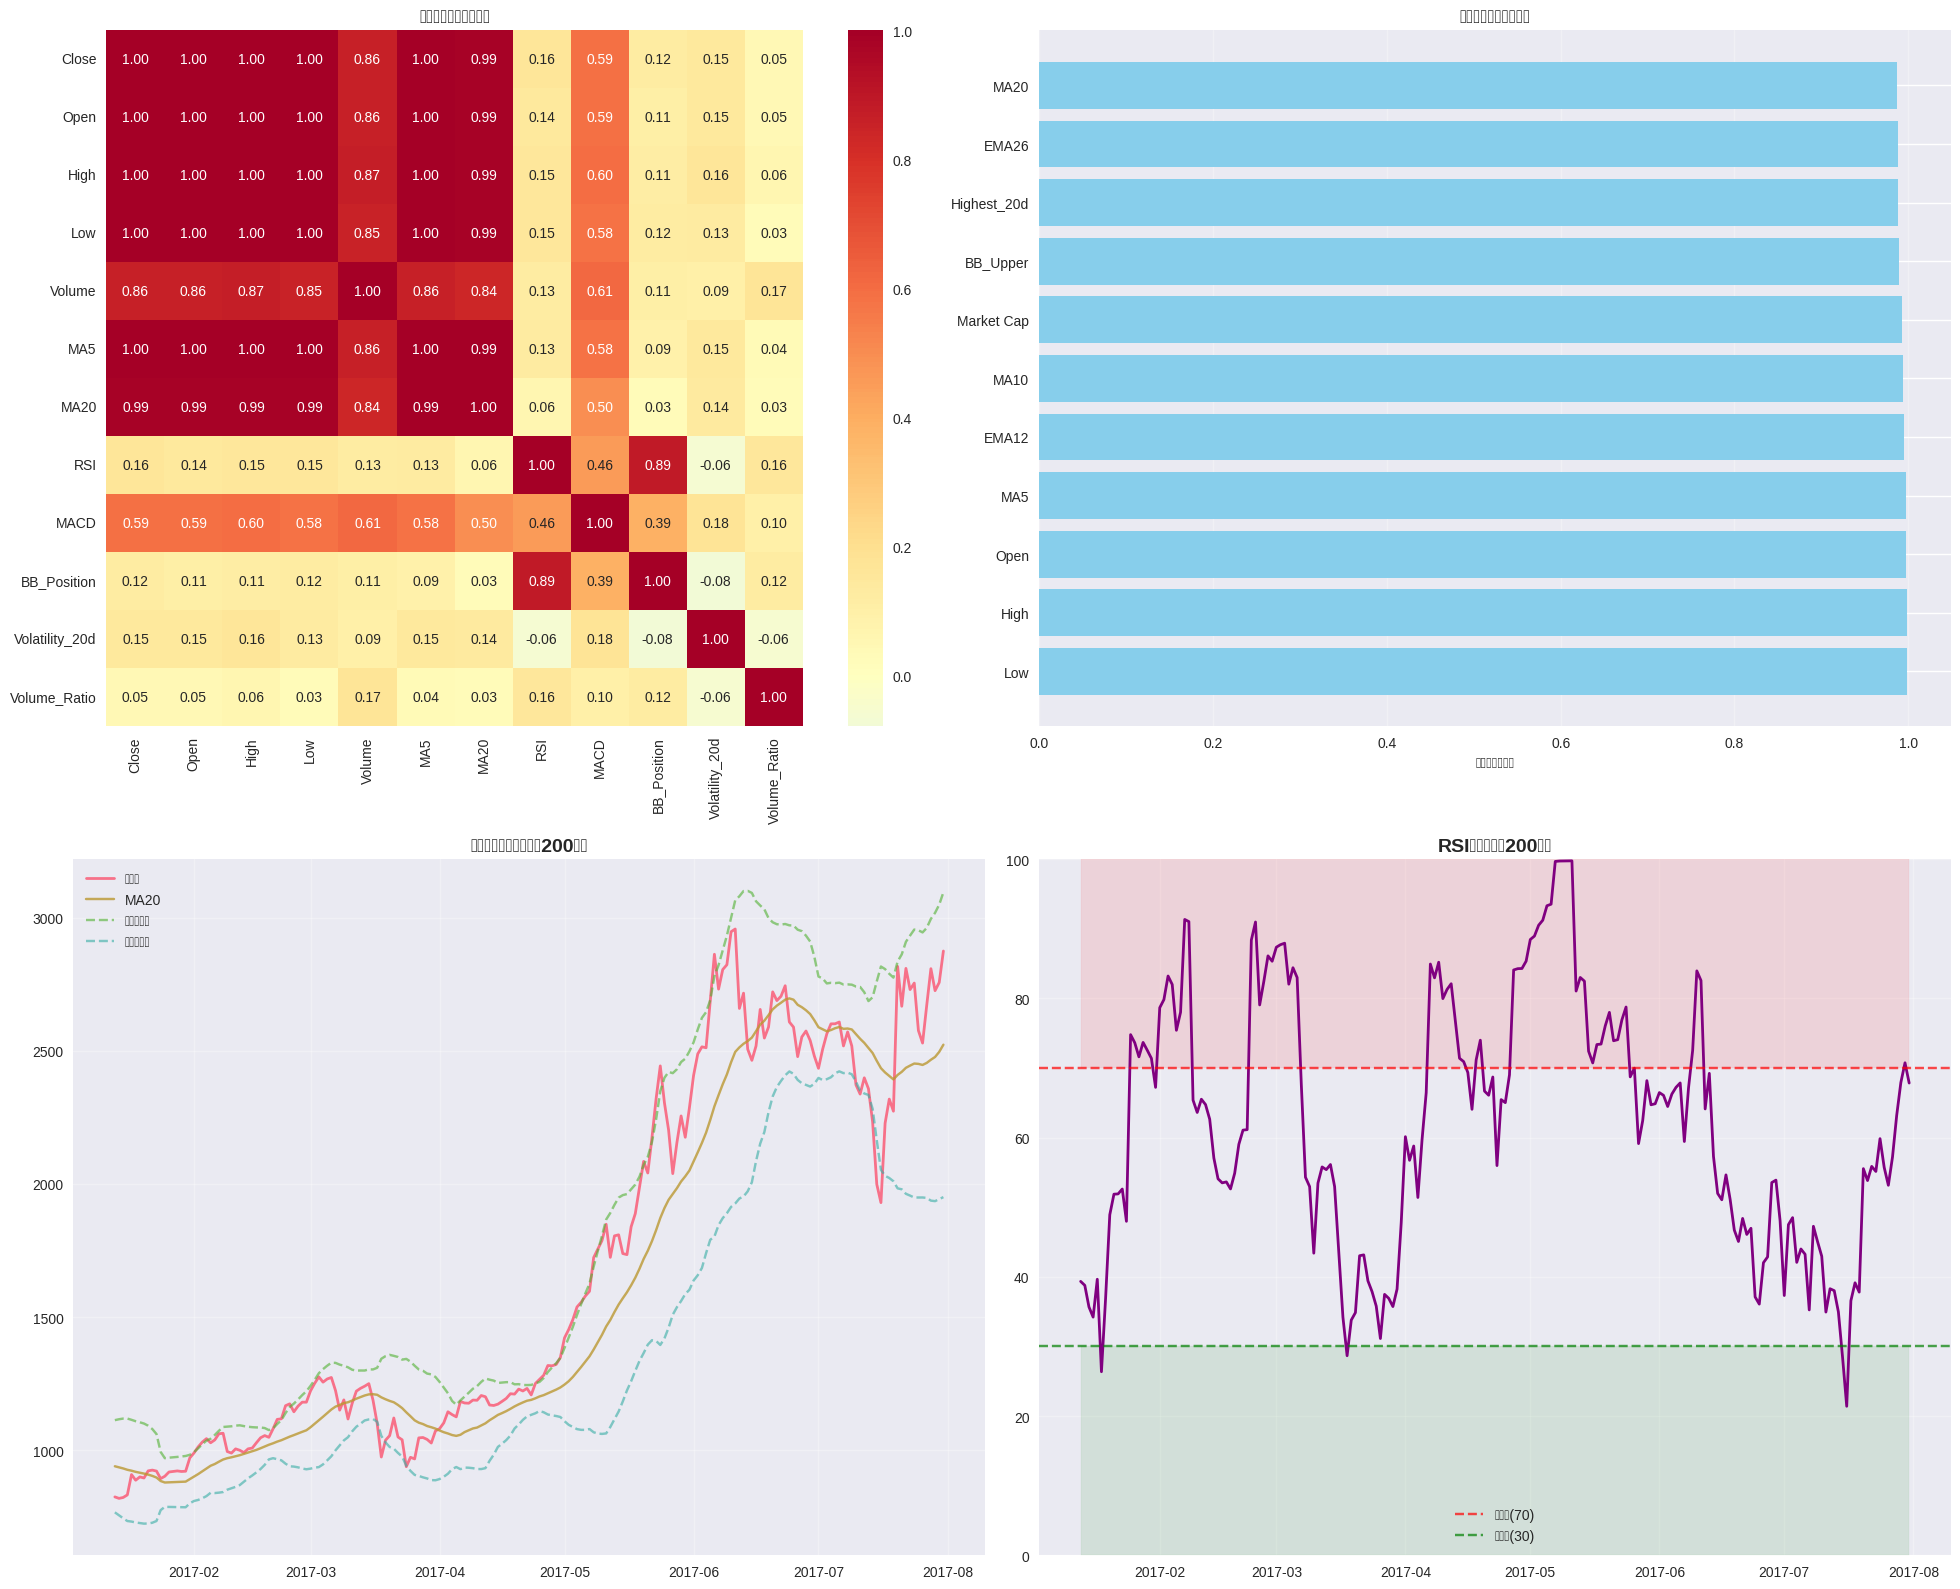


🔍 检查多重共线性...
发现 136 对高度相关的特征 (|r| > 0.9):
  Open <-> High: 0.9986
  Open <-> Low: 0.9982
  Open <-> Close: 0.9975
  Open <-> Market Cap: 0.9952
  Open <-> MA5: 0.9985
  Open <-> MA10: 0.9953
  Open <-> MA20: 0.9889
  Open <-> MA50: 0.9657
  Open <-> EMA12: 0.9960
  Open <-> EMA26: 0.9894


In [78]:
# 计算特征相关性
print("🔍 分析特征相关性...")

# 选择数值特征进行相关性分析
numeric_features = train_features.select_dtypes(include=[np.number]).columns
corr_matrix = train_features[numeric_features].corr()

# 找出与收盘价最相关的特征
close_corr = corr_matrix['Close'].abs().sort_values(ascending=False)
print("\n📈 与收盘价最相关的前15个特征:")
for i, (feature, corr) in enumerate(close_corr.head(15).items(), 1):
    if feature != 'Close':
        print(f"{i:2d}. {feature}: {corr:.4f}")

# 可视化特征相关性热力图
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. 所有特征相关性热力图（抽样显示）
important_features = ['Close', 'Open', 'High', 'Low', 'Volume', 'MA5', 'MA20', 'RSI',
                     'MACD', 'BB_Position', 'Volatility_20d', 'Volume_Ratio']
if all(feat in corr_matrix.columns for feat in important_features):
    sns.heatmap(corr_matrix[important_features].loc[important_features],
                annot=True, cmap='RdYlBu_r', center=0,
                square=True, ax=axes[0,0], fmt='.2f')
    axes[0,0].set_title('主要特征相关性热力图', fontsize=14, fontweight='bold')

# 2. 与收盘价相关性条形图
top_features = close_corr.head(12)
top_features = top_features[top_features.index != 'Close']
axes[0,1].barh(range(len(top_features)), top_features.values, color='skyblue')
axes[0,1].set_yticks(range(len(top_features)))
axes[0,1].set_yticklabels(top_features.index, fontsize=10)
axes[0,1].set_xlabel('相关系数绝对值')
axes[0,1].set_title('与收盘价最相关的特征', fontsize=14, fontweight='bold')
axes[0,1].grid(axis='x', alpha=0.3)

# 3. 技术指标时间序列图
recent_data = train_features.tail(200)  # 最近200天数据
axes[1,0].plot(recent_data.index, recent_data['Close'], label='收盘价', linewidth=2)
axes[1,0].plot(recent_data.index, recent_data['MA20'], label='MA20', alpha=0.8)
axes[1,0].plot(recent_data.index, recent_data['BB_Upper'], label='布林带上轨', alpha=0.6, linestyle='--')
axes[1,0].plot(recent_data.index, recent_data['BB_Lower'], label='布林带下轨', alpha=0.6, linestyle='--')
axes[1,0].set_title('技术指标可视化（最近200天）', fontsize=14, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. RSI指标图
ax_rsi = axes[1,1]
ax_rsi.plot(recent_data.index, recent_data['RSI'], color='purple', linewidth=2)
ax_rsi.axhline(y=70, color='r', linestyle='--', alpha=0.7, label='超买线(70)')
ax_rsi.axhline(y=30, color='g', linestyle='--', alpha=0.7, label='超卖线(30)')
ax_rsi.fill_between(recent_data.index, 70, 100, alpha=0.1, color='red')
ax_rsi.fill_between(recent_data.index, 0, 30, alpha=0.1, color='green')
ax_rsi.set_ylim(0, 100)
ax_rsi.set_title('RSI指标（最近200天）', fontsize=14, fontweight='bold')
ax_rsi.legend()
ax_rsi.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 检查多重共线性
print("\n🔍 检查多重共线性...")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:  # 高度相关
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f"发现 {len(high_corr_pairs)} 对高度相关的特征 (|r| > 0.9):")
    for feat1, feat2, corr in high_corr_pairs[:10]:  # 只显示前10个
        print(f"  {feat1} <-> {feat2}: {corr:.4f}")
else:
    print("✅ 未发现严重的多重共线性问题")

## 4. 数据预处理和序列构建

为LSTM模型准备时间序列数据，包括标准化、滑动窗口构建等。

### 4.1 特征选择和数据清洗

In [79]:
def select_features_for_modeling(df, target_col='Close', max_features=20):
    """
    选择用于建模的特征

    参数:
        df: 特征数据框
        target_col: 目标变量列名
        max_features: 最大特征数量

    返回:
        选择的特征列表
    """
    print(f"🎯 选择建模特征 (最多{max_features}个)...")

    # 计算与目标变量的相关性
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlations = df[numeric_cols].corr()[target_col].abs().sort_values(ascending=False)

    # 移除目标变量本身和高度相关的特征
    selected_features = []
    excluded_features = [target_col]  # 排除目标变量

    # 手动排除一些冗余特征
    redundant_features = [
        'Open', 'High', 'Low',  # 与Close高度相关
        'Market Cap',           # 通常与价格高度相关
        'BB_Middle',           # 与MA20相同
        'Year', 'Day', 'DayOfYear', 'Quarter'  # 时间特征冗余
    ]
    excluded_features.extend(redundant_features)

    print(f"\n📊 特征选择过程:")
    for feature, corr in correlations.items():
        if feature not in excluded_features and len(selected_features) < max_features:
            # 检查与已选择特征的相关性
            if selected_features:
                max_corr_with_selected = df[selected_features + [feature]].corr()[feature][:-1].abs().max()
                if max_corr_with_selected < 0.85:  # 避免多重共线性
                    selected_features.append(feature)
                    print(f"  ✅ {feature}: 相关性={corr:.4f}")
                else:
                    print(f"  ❌ {feature}: 相关性={corr:.4f} (与已选特征相关性过高: {max_corr_with_selected:.4f})")
            else:
                selected_features.append(feature)
                print(f"  ✅ {feature}: 相关性={corr:.4f}")
        elif feature in excluded_features:
            print(f"  🚫 {feature}: 相关性={corr:.4f} (已排除)")

    print(f"\n✅ 最终选择 {len(selected_features)} 个特征用于建模")
    return selected_features

# 选择建模特征
selected_features = select_features_for_modeling(train_features)
print(f"\n📋 选择的特征: {selected_features}")

🎯 选择建模特征 (最多20个)...

📊 特征选择过程:
  🚫 Close: 相关性=1.0000 (已排除)
  🚫 Low: 相关性=0.9988 (已排除)
  🚫 High: 相关性=0.9986 (已排除)
  🚫 Open: 相关性=0.9975 (已排除)
  ✅ MA5: 相关性=0.9972
  ❌ EMA12: 相关性=0.9946 (与已选特征相关性过高: 0.9983)
  ❌ MA10: 相关性=0.9937 (与已选特征相关性过高: 0.9981)
  🚫 Market Cap: 相关性=0.9930 (已排除)
  ❌ BB_Upper: 相关性=0.9892 (与已选特征相关性过高: 0.9930)
  ❌ Highest_20d: 相关性=0.9886 (与已选特征相关性过高: 0.9918)
  ❌ EMA26: 相关性=0.9877 (与已选特征相关性过高: 0.9924)
  ❌ MA20: 相关性=0.9870 (与已选特征相关性过高: 0.9923)
  🚫 BB_Middle: 相关性=0.9870 (已排除)
  ❌ Lowest_20d: 相关性=0.9708 (与已选特征相关性过高: 0.9764)
  ❌ MA50: 相关性=0.9639 (与已选特征相关性过高: 0.9694)
  ❌ BB_Lower: 相关性=0.9634 (与已选特征相关性过高: 0.9705)
  ❌ Volume_MA: 相关性=0.9016 (与已选特征相关性过高: 0.9035)
  ❌ Volume: 相关性=0.8609 (与已选特征相关性过高: 0.8576)
  ✅ BB_Width: 相关性=0.8100
  ✅ MACD_Signal: 相关性=0.6209
  ❌ MACD: 相关性=0.5936 (与已选特征相关性过高: 0.9620)
  ✅ Days_Since_Start: 相关性=0.5935
  🚫 Year: 相关性=0.5899 (已排除)
  ✅ Momentum: 相关性=0.3514
  ✅ Price_Above_MA50: 相关性=0.2608
  ✅ RSI: 相关性=0.1576
  ✅ Volatility_20d: 相关性=0.1477
  ✅ Month_cos: 相关性=0

In [80]:
# 准备建模数据
modeling_features = selected_features + ['Close']  # 包含目标变量
train_modeling = train_features[modeling_features].copy()
test_modeling = test_features[modeling_features].copy()

# 处理缺失值
print(f"\n🔧 处理缺失值...")
print(f"训练数据缺失值: {train_modeling.isnull().sum().sum()}")
print(f"测试数据缺失值: {test_modeling.isnull().sum().sum()}")


🔧 处理缺失值...
训练数据缺失值: 97
测试数据缺失值: 50


In [81]:
# 删除包含缺失值的行（主要是由于技术指标计算窗口期导致的前几行）
# For training data, drop rows with NaNs
train_clean = train_modeling.dropna()

# For test data, do NOT drop rows with NaNs, handle them when creating sequences
test_clean = test_modeling.copy() # Keep the filled data from process_dataframe

print(f"\n✅ 数据清洗完成:")
print(f"训练数据: {train_modeling.shape} -> {train_clean.shape}")
print(f"测试数据: {test_modeling.shape} -> {test_clean.shape}") # Update shapes to show filled data
print(f"训练数据日期范围: {train_clean.index.min()} 到 {train_clean.index.max()}")
print(f"测试数据日期范围: {test_clean.index.min()} 到 {test_clean.index.max()}") # Update date range


✅ 数据清洗完成:
训练数据: (1556, 21) -> (1535, 21)
测试数据: (7, 21) -> (7, 21)
训练数据日期范围: 2013-05-18 00:00:00 到 2017-07-31 00:00:00
测试数据日期范围: 2017-08-01 00:00:00 到 2017-08-07 00:00:00


### 4.2 数据标准化

📊 数据分离结果:
X_train形状: (1535, 20)
y_train形状: (1535,)
X_test形状: (7, 20)
y_test形状: (7,)

🔧 进行特征标准化...
✅ 标准化完成
特征标准化范围: [0.0000, 1.0000]
目标标准化范围: [0.0000, 1.0000]


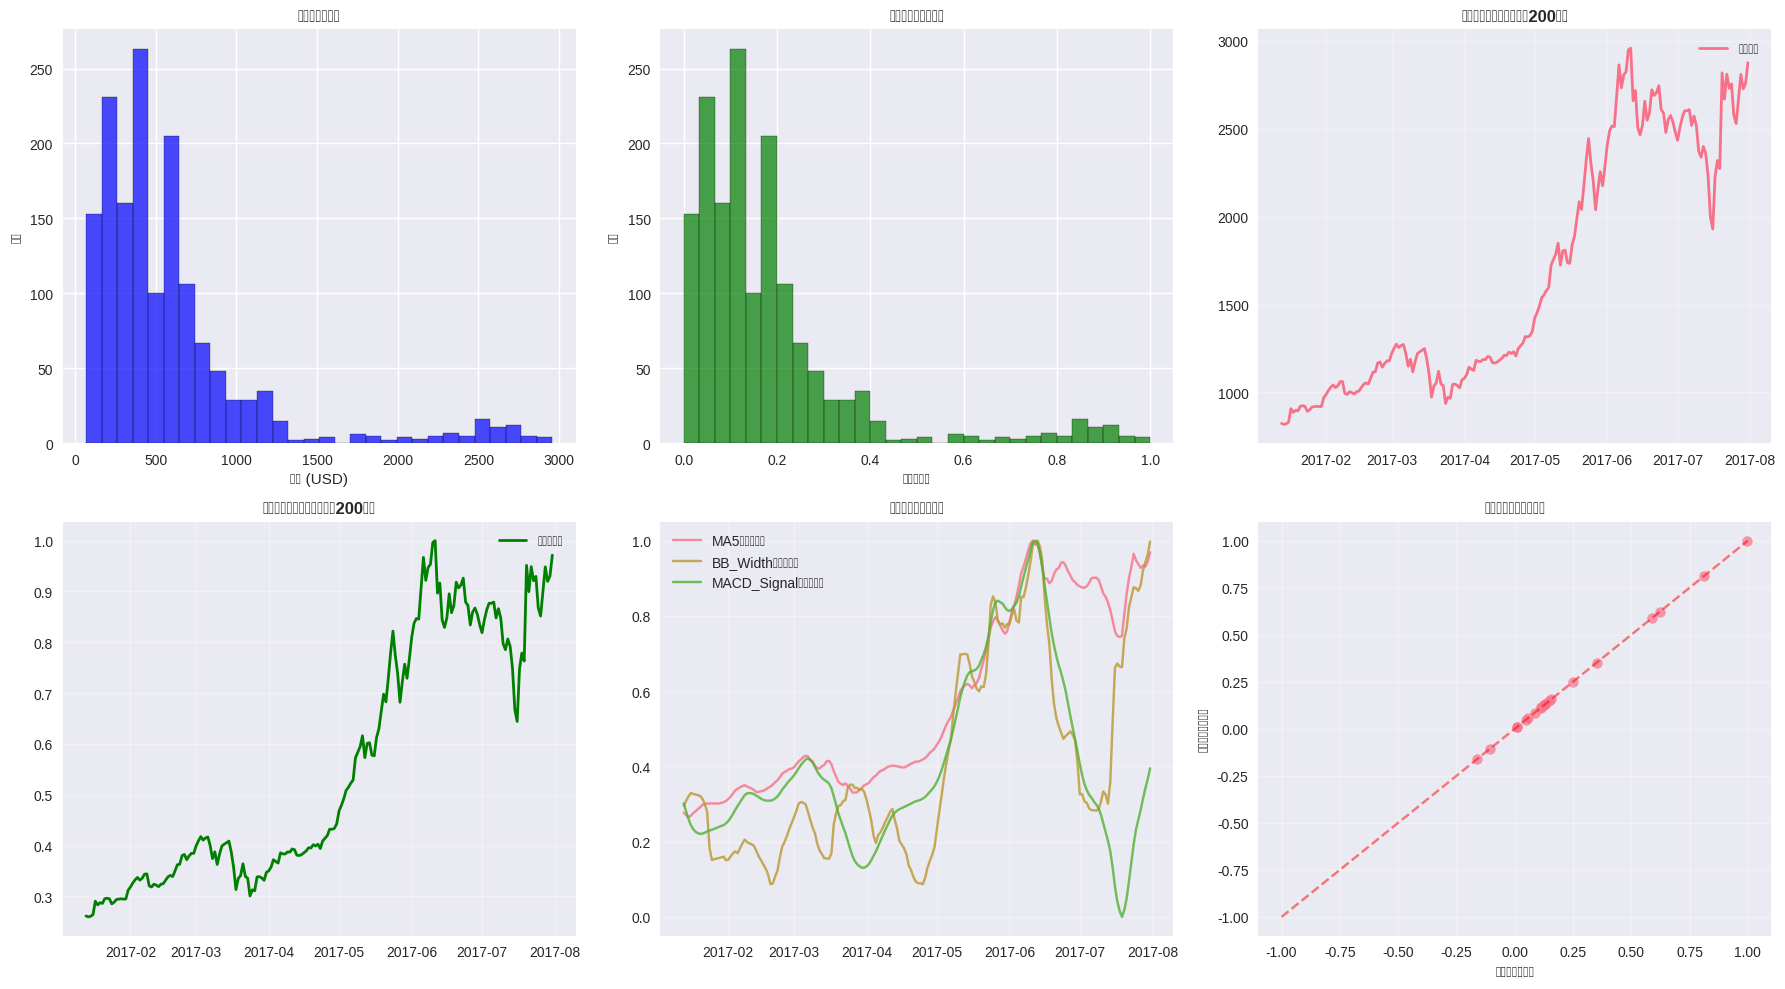


📈 标准化效果验证:
原始目标变量 - 均值: 590.63, 标准差: 526.62
标准化目标变量 - 均值: 0.1807, 标准差: 0.1822
相关性保持度: 1.0000


In [82]:
# 分离特征和目标变量
X_train = train_clean[selected_features]
y_train = train_clean['Close']
X_test = test_clean[selected_features]
y_test = test_clean['Close']

print(f"📊 数据分离结果:")
print(f"X_train形状: {X_train.shape}")
print(f"y_train形状: {y_train.shape}")
print(f"X_test形状: {X_test.shape}")
print(f"y_test形状: {y_test.shape}")

# 特征标准化
print(f"\n🔧 进行特征标准化...")

# 创建标准化器
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# 拟合并转换训练数据
X_train_scaled = feature_scaler.fit_transform(X_train)
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

# 转换测试数据（使用训练数据的标准化参数）
X_test_scaled = feature_scaler.transform(X_test)
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print(f"✅ 标准化完成")
print(f"特征标准化范围: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"目标标准化范围: [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]")

# 可视化标准化前后的数据分布
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 原始数据分布
axes[0,0].hist(train_clean['Close'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('原始收盘价分布', fontweight='bold')
axes[0,0].set_xlabel('价格 (USD)')
axes[0,0].set_ylabel('频次')

# 标准化后分布
axes[0,1].hist(y_train_scaled, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0,1].set_title('标准化后收盘价分布', fontweight='bold')
axes[0,1].set_xlabel('标准化价格')
axes[0,1].set_ylabel('频次')

# 时间序列对比
recent_idx = -200  # 最近200天
axes[0,2].plot(train_clean.index[recent_idx:], train_clean['Close'].iloc[recent_idx:],
               label='原始价格', linewidth=2)
axes[0,2].set_title('原始价格时间序列（最近200天）', fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

axes[1,0].plot(train_clean.index[recent_idx:], y_train_scaled[recent_idx:],
               label='标准化价格', color='green', linewidth=2)
axes[1,0].set_title('标准化价格时间序列（最近200天）', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 特征标准化示例（选择几个重要特征）
important_feature_idx = [0, 1, 2]  # 前3个特征
for i, idx in enumerate(important_feature_idx):
    if idx < X_train.shape[1]:
        feature_name = selected_features[idx]
        axes[1,1].plot(train_clean.index[recent_idx:], X_train_scaled[recent_idx:, idx],
                      label=f'{feature_name}（标准化）', alpha=0.8)

axes[1,1].set_title('主要特征标准化结果', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 相关性对比
original_corr = np.corrcoef(X_train.T, y_train)[:-1, -1]
scaled_corr = np.corrcoef(X_train_scaled.T, y_train_scaled)[:-1, -1]

axes[1,2].scatter(original_corr, scaled_corr, alpha=0.7, s=50)
axes[1,2].plot([-1, 1], [-1, 1], 'r--', alpha=0.5)
axes[1,2].set_xlabel('原始数据相关性')
axes[1,2].set_ylabel('标准化数据相关性')
axes[1,2].set_title('标准化前后相关性对比', fontweight='bold')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 标准化效果验证:")
print(f"原始目标变量 - 均值: {y_train.mean():.2f}, 标准差: {y_train.std():.2f}")
print(f"标准化目标变量 - 均值: {y_train_scaled.mean():.4f}, 标准差: {y_train_scaled.std():.4f}")
print(f"相关性保持度: {np.corrcoef(original_corr, scaled_corr)[0,1]:.4f}")

### 4.3 时间序列序列构建

In [84]:
import numpy as np

def create_sequences(X, y, sequence_length=60, prediction_horizon=1):
    """
    创建用于LSTM的时间序列序列

    参数:
        X: 特征数据 (samples, features)
        y: 目标数据 (samples,)
        sequence_length: 输入序列长度（回看窗口）
        prediction_horizon: 预测步长（向前预测几步）

    返回:
        X_sequences: 序列特征 (samples, sequence_length, features)
        y_sequences: 序列目标 (samples,)
    """
    print(f"🔧 创建时间序列，序列长度: {sequence_length}, 预测步长: {prediction_horizon}")

    X_sequences, y_sequences = [], []

    for i in range(sequence_length, len(X) - prediction_horizon + 1):
        # 输入序列：过去sequence_length天的特征
        X_sequences.append(X[i-sequence_length:i])

        # 目标：prediction_horizon步后的收盘价
        y_sequences.append(y[i + prediction_horizon - 1])

    X_sequences = np.array(X_sequences)
    y_sequences = np.array(y_sequences)

    print(f"✅ 序列创建完成:")
    print(f"   输入序列形状: {X_sequences.shape} (样本数, 序列长度, 特征数)")
    print(f"   目标序列形状: {y_sequences.shape}")
    print(f"   有效样本数: {len(y_sequences)}")

    return X_sequences, y_sequences


def analyze_sequence_length_impact(X, y, sequence_lengths=[30, 60, 90, 120]):
    """
    分析不同序列长度对数据量的影响

    参数:
        X: 特征数据
        y: 目标数据
        sequence_lengths: 要测试的序列长度列表
    """
    print(f"\n📊 分析不同序列长度的影响:")
    print(f"原始数据量: {len(X)}")
    print("-" * 50)

    results = []
    for seq_len in sequence_lengths:
        valid_samples = len(X) - seq_len
        data_loss_pct = (seq_len / len(X)) * 100
        results.append({
            'sequence_length': seq_len,
            'valid_samples': valid_samples,
            'data_loss_pct': data_loss_pct
        })
        print(f"序列长度 {seq_len:3d}: 有效样本 {valid_samples:4d}, 数据损失 {data_loss_pct:5.1f}%")

    return results


# 分析序列长度影响
sequence_analysis = analyze_sequence_length_impact(X_train_scaled, y_train_scaled)

# 选择序列长度
SEQUENCE_LENGTH = 60  # 使用60天的历史数据预测下一天
PREDICTION_HORIZON = 1  # 预测下一天

print(f"\n🎯 选择序列参数:")
print(f"序列长度: {SEQUENCE_LENGTH} 天")
print(f"预测步长: {PREDICTION_HORIZON} 天")

# 创建训练序列
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_scaled,
    sequence_length=SEQUENCE_LENGTH,
    prediction_horizon=PREDICTION_HORIZON
)

# 为测试集创建序列（需要连接训练和测试数据以保持连续性）
print(f"\n🔧 处理测试集序列...")

if len(X_test_scaled) < SEQUENCE_LENGTH:
    print(f"⚠️ 测试集长度({len(X_test_scaled)})小于序列长度({SEQUENCE_LENGTH})")
    print(f"将使用训练集最后{SEQUENCE_LENGTH}天数据构建测试序列")

    X_combined = np.vstack([X_train_scaled[-(SEQUENCE_LENGTH):], X_test_scaled])
    y_combined = np.concatenate([y_train_scaled[-(SEQUENCE_LENGTH):], y_test_scaled])

    X_test_seq, y_test_seq = create_sequences(
        X_combined, y_combined,
        sequence_length=SEQUENCE_LENGTH,
        prediction_horizon=PREDICTION_HORIZON
    )

    X_test_seq = X_test_seq[-len(y_test_scaled):]
    y_test_seq = y_test_seq[-len(y_test_scaled):]
else:
    X_test_seq, y_test_seq = create_sequences(
        X_test_scaled, y_test_scaled,
        sequence_length=SEQUENCE_LENGTH,
        prediction_horizon=PREDICTION_HORIZON
    )

print(f"\n✅ 序列构建完成:")
print(f"训练序列: X{X_train_seq.shape}, y{y_train_seq.shape}")
print(f"测试序列: X{X_test_seq.shape}, y{y_test_seq.shape}")

# 进一步分割训练集为训练和验证
VALIDATION_SPLIT = 0.2
split_idx = int(len(X_train_seq) * (1 - VALIDATION_SPLIT))

X_train_final = X_train_seq[:split_idx]
y_train_final = y_train_seq[:split_idx]
X_val_final = X_train_seq[split_idx:]
y_val_final = y_train_seq[split_idx:]

print(f"\n📊 最终数据分割:")
print(f"训练集: X{X_train_final.shape}, y{y_train_final.shape}")
print(f"验证集: X{X_val_final.shape}, y{y_val_final.shape}")
print(f"测试集: X{X_test_seq.shape}, y{y_test_seq.shape}")



📊 分析不同序列长度的影响:
原始数据量: 1535
--------------------------------------------------
序列长度  30: 有效样本 1505, 数据损失   2.0%
序列长度  60: 有效样本 1475, 数据损失   3.9%
序列长度  90: 有效样本 1445, 数据损失   5.9%
序列长度 120: 有效样本 1415, 数据损失   7.8%

🎯 选择序列参数:
序列长度: 60 天
预测步长: 1 天
🔧 创建时间序列，序列长度: 60, 预测步长: 1
✅ 序列创建完成:
   输入序列形状: (1475, 60, 20) (样本数, 序列长度, 特征数)
   目标序列形状: (1475,)
   有效样本数: 1475

🔧 处理测试集序列...
⚠️ 测试集长度(7)小于序列长度(60)
将使用训练集最后60天数据构建测试序列
🔧 创建时间序列，序列长度: 60, 预测步长: 1
✅ 序列创建完成:
   输入序列形状: (7, 60, 20) (样本数, 序列长度, 特征数)
   目标序列形状: (7,)
   有效样本数: 7

✅ 序列构建完成:
训练序列: X(1475, 60, 20), y(1475,)
测试序列: X(7, 60, 20), y(7,)

📊 最终数据分割:
训练集: X(1180, 60, 20), y(1180,)
验证集: X(295, 60, 20), y(295,)
测试集: X(7, 60, 20), y(7,)


In [85]:
# 数据形状验证
print(f"\n🔍 数据形状验证:")
print(f"输入特征维度: {X_train_final.shape[-1]}")
print(f"序列长度: {X_train_final.shape[1]}")
print(f"批次样本数 - 训练: {X_train_final.shape[0]}, 验证: {X_val_final.shape[0]}, 测试: {X_test_seq.shape[0]}")


🔍 数据形状验证:
输入特征维度: 20
序列长度: 60
批次样本数 - 训练: 1180, 验证: 295, 测试: 7


## LSTM模型构建、训练、评估与应用

## 5. LSTM模型架构设计

设计并构建适合时间序列预测的LSTM神经网络模型。

### 5.1 LSTM理论回顾

**LSTM的核心组件：**

1. **遗忘门 (Forget Gate)**
   - 决定从核状态中丢弃什么信息
   - 公式：$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$

2. **输入门 (Input Gate)**
   - 决定在核状态中存储什么新信息
   - 公式：$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$

3. **候选值 (Candidate Values)**
   - 创建新的候选值向量
   - 公式：$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$

4. **核状态更新 (Cell State Update)**
   - 更新核状态
   - 公式：$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$

5. **输出门 (Output Gate)**
   - 决定输出什么部分的核状态
   - 公式：$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$
   - 隐藏状态：$h_t = o_t * \tanh(C_t)$

**为什么LSTM适合时间序列预测：**
- 能够学习长期依赖关系
- 通过门控机制选择性地保留和遗忘信息
- 避免了传统RNN的梯度消失问题
- 能够处理变长的输入序列

### 5.2 模型架构实现

In [91]:
def create_lstm_model(input_shape, model_config=None):
    """
    创建LSTM时间序列预测模型

    参数:
        input_shape: 输入形状 (sequence_length, n_features)
        model_config: 模型配置字典

    返回:
        编译好的Keras模型
    """
    # 默认配置
    default_config = {
        'lstm_units': [64, 32],      # LSTM层单元数
        'dense_units': [16],         # 全连接层单元数
        'dropout_rate': 0.2,         # Dropout比例
        'recurrent_dropout': 0.2,    # 循环Dropout比例
        'activation': 'relu',        # 激活函数
        'optimizer': 'adam',         # 优化器
        'learning_rate': 0.001,      # 学习率
        'loss': 'mse',              # 损失函数
        'use_bidirectional': False,  # 是否使用双向LSTM
        'l2_regularization': 0.01    # L2正则化
    }

    if model_config:
        default_config.update(model_config)
    config = default_config

    print(f"🏗️ 构建LSTM模型...")
    print(f"输入形状: {input_shape}")
    print(f"模型配置: {config}")

    # 构建模型
    model = Sequential(name='Bitcoin_LSTM_Model')

    # 第一层LSTM
    if config['use_bidirectional']:
        model.add(Bidirectional(
            LSTM(
                units=config['lstm_units'][0],
                return_sequences=len(config['lstm_units']) > 1,
                dropout=config['dropout_rate'],
                recurrent_dropout=config['recurrent_dropout'],
                kernel_regularizer=l2(config['l2_regularization']),
                name='bidirectional_lstm_1'
            ),
            input_shape=input_shape,
            name='bidirectional_wrapper_1'
        ))
    else:
        model.add(LSTM(
            units=config['lstm_units'][0],
            return_sequences=len(config['lstm_units']) > 1,
            input_shape=input_shape,
            dropout=config['dropout_rate'],
            recurrent_dropout=config['recurrent_dropout'],
            kernel_regularizer=l2(config['l2_regularization']),
            name='lstm_1'
        ))

    # Additional LSTM layers
    for i, units in enumerate(config['lstm_units'][1:], 2):
        return_seq = i < len(config['lstm_units'])

        if config['use_bidirectional']:
            model.add(Bidirectional(
                LSTM(
                    units=units,
                    return_sequences=return_seq,
                    dropout=config['dropout_rate'],
                    recurrent_dropout=config['recurrent_dropout'],
                    kernel_regularizer=l2(config['l2_regularization']),
                    name=f'bidirectional_lstm_{i}'
                ),
                name=f'bidirectional_wrapper_{i}'
            ))
        else:
            model.add(LSTM(
                units=units,
                return_sequences=return_seq,
                dropout=config['dropout_rate'],
                recurrent_dropout=config['recurrent_dropout'],
                kernel_regularizer=l2(config['l2_regularization']),
                name=f'lstm_{i}'
            ))

    # Dropout layer
    model.add(Dropout(config['dropout_rate'], name='dropout_main'))

    # Dense layers
    for i, units in enumerate(config['dense_units'], 1):
        model.add(Dense(
            units=units,
            activation=config['activation'],
            kernel_regularizer=l2(config['l2_regularization']),
            name=f'dense_{i}'
        ))
        model.add(Dropout(config['dropout_rate'], name=f'dropout_{i}'))

    # Output layer
    model.add(Dense(1, activation='linear', name='output'))

    # Explicitly build the model
    model.build(input_shape=(None, *input_shape))


    # Compile the model
    if config['optimizer'] == 'adam':
        optimizer = Adam(learning_rate=config['learning_rate'])
    elif config['optimizer'] == 'rmsprop':
        optimizer = RMSprop(learning_rate=config['learning_rate'])
    else:
        optimizer = config['optimizer']

    model.compile(
        optimizer=optimizer,
        loss=config['loss'],
        metrics=['mae', 'mse']
    )

    print(f"✅ 模型构建完成!")

    return model, config

# 创建不同配置的模型进行对比
model_configs = {
    'baseline': {
        'lstm_units': [50],
        'dense_units': [25],
        'dropout_rate': 0.2
    },
    'deep_lstm': {
        'lstm_units': [64, 32],
        'dense_units': [16],
        'dropout_rate': 0.3
    },
    'bidirectional': {
        'lstm_units': [32],
        'dense_units': [16],
        'dropout_rate': 0.25,
        'use_bidirectional': True
    }
}

# 创建基线模型
input_shape = (X_train_final.shape[1], X_train_final.shape[2])
model, config = create_lstm_model(input_shape, model_configs['deep_lstm'])

# 显示模型结构
print("\n📋 模型结构:")
model.summary()

# 可视化模型架构
try:
    from tensorflow.keras.utils import plot_model
    plot_model(model, to_file='bitcoin_lstm_model.png',
               show_shapes=True, show_layer_names=True, dpi=150)
    print("\n🖼️ 模型架构图已保存为 bitcoin_lstm_model.png")
except Exception as e:
    print(f"\n⚠️ 无法生成模型架构图: {e}")

# 计算模型参数
total_params = model.count_params()
print(f"\n📊 模型参数统计:")
print(f"总参数数量: {total_params:,}")
print(f"模型大小估计: {total_params * 4 / 1024 / 1024:.2f} MB (float32)")

# 显示各层参数数量
print(f"\n📋 各层参数详情:")
for i, layer in enumerate(model.layers):
    params = layer.count_params()
    if params > 0:
        print(f"{i+1:2d}. {layer.name}: {params:,} 参数")

🏗️ 构建LSTM模型...
输入形状: (60, 20)
模型配置: {'lstm_units': [64, 32], 'dense_units': [16], 'dropout_rate': 0.3, 'recurrent_dropout': 0.2, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001, 'loss': 'mse', 'use_bidirectional': False, 'l2_regularization': 0.01}
✅ 模型构建完成!

📋 模型结构:


Model: "Bitcoin_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_main (Dropout)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)


🖼️ 模型架构图已保存为 bitcoin_lstm_model.png

📊 模型参数统计:
总参数数量: 34,721
模型大小估计: 0.13 MB (float32)

📋 各层参数详情:
 1. lstm_1: 21,760 参数
 2. lstm_2: 12,416 参数
 4. dense_1: 528 参数
 6. output: 17 参数


### 5.3 训练策略和回调函数设置

In [89]:
# 训练参数设置
training_config = {
    'batch_size': 32,           # 批次大小
    'epochs': 10,              # 最大训练轮数
    'patience': 15,             # 早停耐心值
    'min_delta': 0.0001,        # 最小改善幅度
    'factor': 0.5,              # 学习率衰减因子
    'lr_patience': 7,           # 学习率调度耐心值
    'min_lr': 1e-7              # 最小学习率
}

print(f"🎯 训练配置:")
for key, value in training_config.items():
    print(f"  {key}: {value}")

# 创建回调函数
callbacks_list = []

# 1. 早停回调
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=training_config['patience'],
    min_delta=training_config['min_delta'],
    restore_best_weights=True,
    verbose=1,
    mode='min'
)
callbacks_list.append(early_stopping)

# 2. 学习率调度
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=training_config['factor'],
    patience=training_config['lr_patience'],
    min_lr=training_config['min_lr'],
    verbose=1,
    mode='min'
)
callbacks_list.append(reduce_lr)

# 3. 模型检查点
checkpoint = ModelCheckpoint(
    filepath='best_bitcoin_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
    mode='min'
)
callbacks_list.append(checkpoint)

# 4. TensorBoard日志（可选）
try:
    from datetime import datetime
    log_dir = f"logs/bitcoin_lstm_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    tensorboard = TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        update_freq='epoch'
    )
    callbacks_list.append(tensorboard)
    print(f"✅ TensorBoard日志将保存到: {log_dir}")
except Exception as e:
    print(f"⚠️ TensorBoard设置失败: {e}")

print(f"\n📋 配置的回调函数:")
for i, callback in enumerate(callbacks_list, 1):
    print(f"{i}. {callback.__class__.__name__}")

# 数据验证
print(f"\n🔍 训练前数据验证:")
print(f"训练数据形状: X{X_train_final.shape}, y{y_train_final.shape}")
print(f"验证数据形状: X{X_val_final.shape}, y{y_val_final.shape}")
print(f"数据类型: X{X_train_final.dtype}, y{y_train_final.dtype}")
print(f"数据范围: X[{X_train_final.min():.4f}, {X_train_final.max():.4f}], y[{y_train_final.min():.4f}, {y_train_final.max():.4f}]")

# 检查是否有异常值
if np.isnan(X_train_final).any() or np.isnan(y_train_final).any():
    print("❌ 警告: 训练数据包含NaN值")
else:
    print("✅ 数据验证通过")

🎯 训练配置:
  batch_size: 32
  epochs: 10
  patience: 15
  min_delta: 0.0001
  factor: 0.5
  lr_patience: 7
  min_lr: 1e-07
✅ TensorBoard日志将保存到: logs/bitcoin_lstm_20250902_021248

📋 配置的回调函数:
1. EarlyStopping
2. ReduceLROnPlateau
3. ModelCheckpoint
4. TensorBoard

🔍 训练前数据验证:
训练数据形状: X(1180, 60, 20), y(1180,)
验证数据形状: X(295, 60, 20), y(295,)
数据类型: Xfloat64, yfloat64
数据范围: X[0.0000, 1.0000], y[0.0073, 0.3747]
✅ 数据验证通过


## 6. 模型训练

In [92]:
# 开始训练
print("🚀 开始训练LSTM模型...")
print("=" * 60)

import time
start_time = time.time()

# 训练模型
history = model.fit(
    X_train_final, y_train_final,
    batch_size=training_config['batch_size'],
    epochs=training_config['epochs'],
    validation_data=(X_val_final, y_val_final),
    callbacks=callbacks_list,
    verbose=1,
    shuffle=False  # 对于时间序列，通常不打乱顺序
)

training_time = time.time() - start_time

print(f"\n✅ 训练完成!")
print(f"训练用时: {training_time:.2f} 秒 ({training_time/60:.1f} 分钟)")
print(f"实际训练轮数: {len(history.history['loss'])}")
print(f"最佳验证损失: {min(history.history['val_loss']):.6f}")
print(f"最终训练损失: {history.history['loss'][-1]:.6f}")
print(f"最终验证损失: {history.history['val_loss'][-1]:.6f}")

🚀 开始训练LSTM模型...
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 1.2925 - mae: 0.1554 - mse: 0.0425
Epoch 1: val_loss improved from inf to 1.04062, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - loss: 1.2885 - mae: 0.1549 - mse: 0.0422 - val_loss: 1.0406 - val_mae: 0.3753 - val_mse: 0.2022 - learning_rate: 0.0010
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.7522 - mae: 0.0863 - mse: 0.0123
Epoch 2: val_loss improved from 1.04062 to 0.70000, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - loss: 0.7498 - mae: 0.0861 - mse: 0.0122 - val_loss: 0.7000 - val_mae: 0.3932 - val_mse: 0.2137 - learning_rate: 0.0010
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.4396 - mae: 0.0818 - mse: 0.0101
Epoch 3: val_loss improved from 0.70000 to 0.48109, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.4382 - mae: 0.0815 - mse: 0.0100 - val_loss: 0.4811 - val_mae: 0.3702 - val_mse: 0.1963 - learning_rate: 0.0010
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.2614 - mae: 0.0769 - mse: 0.0088
Epoch 4: val_loss improved from 0.48109 to 0.35803, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - loss: 0.2606 - mae: 0.0766 - mse: 0.0088 - val_loss: 0.3580 - val_mae: 0.3593 - val_mse: 0.1876 - learning_rate: 0.0010
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.1607 - mae: 0.0771 - mse: 0.0086
Epoch 5: val_loss improved from 0.35803 to 0.28936, saving model to best_bitcoin_lstm_model.h5


...

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - loss: 0.1020 - mae: 0.0757 - mse: 0.0080 - val_loss: 0.2482 - val_mae: 0.3490 - val_mse: 0.1817 - learning_rate: 0.0010
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0679 - mae: 0.0753 - mse: 0.0078
Epoch 7: val_loss improved from 0.24822 to 0.22268, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0677 - mae: 0.0749 - mse: 0.0077 - val_loss: 0.2227 - val_mae: 0.3458 - val_mse: 0.1795 - learning_rate: 0.0010
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0469 - mae: 0.0748 - mse: 0.0077
Epoch 8: val_loss improved from 0.22268 to 0.20653, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - loss: 0.0467 - mae: 0.0744 - mse: 0.0077 - val_loss: 0.2065 - val_mae: 0.3436 - val_mse: 0.1780 - learning_rate: 0.0010
Epoch 9/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0337 - mae: 0.0748 - mse: 0.0078
Epoch 9: val_loss improved from 0.20653 to 0.19659, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0336 - mae: 0.0744 - mse: 0.0077 - val_loss: 0.1966 - val_mae: 0.3430 - val_mse: 0.1776 - learning_rate: 0.0010
Epoch 10/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0250 - mae: 0.0747 - mse: 0.0077
Epoch 10: val_loss improved from 0.19659 to 0.18980, saving model to best_bitcoin_lstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0249 - mae: 0.0743 - mse: 0.0076 - val_loss: 0.1898 - val_mae: 0.3423 - val_mse: 0.1771 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

✅ 训练完成!
训练用时: 79.48 秒 (1.3 分钟)
实际训练轮数: 10
最佳验证损失: 0.189797
最终训练损失: 0.020835
最终验证损失: 0.189797


### 6.1 训练过程可视化

In [95]:
# 训练历史可视化
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '损失函数变化',
        '平均绝对误差变化',
        '学习率变化',
        '训练vs验证损失对比'
    ),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

epochs = range(1, len(history.history['loss']) + 1)

# 1. 损失函数变化
fig.add_trace(
    go.Scatter(
        x=list(epochs),
        y=history.history['loss'],
        mode='lines',
        name='训练损失',
        line=dict(color='blue', width=2)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=list(epochs),
        y=history.history['val_loss'],
        mode='lines',
        name='验证损失',
        line=dict(color='red', width=2)
    ),
    row=1, col=1
)

# 2. MAE变化
fig.add_trace(
    go.Scatter(
        x=list(epochs),
        y=history.history['mae'],
        mode='lines',
        name='训练MAE',
        line=dict(color='green', width=2)
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(
        x=list(epochs),
        y=history.history['val_mae'],
        mode='lines',
        name='验证MAE',
        line=dict(color='orange', width=2)
    ),
    row=1, col=2
)

# 3. 学习率变化（如果有记录）
if 'learning_rate' in history.history:
    fig.add_trace(
        go.Scatter(
            x=list(epochs),
            y=history.history['learning_rate'],
            mode='lines',
            name='学习率',
            line=dict(color='purple', width=2)
        ),
        row=2, col=1
    )
    fig.update_yaxes(type="log", row=2, col=1)
else:
    fig.add_annotation(
        text="学习率数据不可用",
        xref="x3", yref="y3",
        x=0.5, y=0.5,
        showarrow=False,
        row=2, col=1
    )

# 4. 损失比较和过拟合分析
train_val_diff = np.array(history.history['loss']) - np.array(history.history['val_loss'])
fig.add_trace(
    go.Scatter(
        x=list(epochs),
        y=train_val_diff,
        mode='lines',
        name='训练-验证损失差',
        line=dict(color='brown', width=2)
    ),
    row=2, col=2
)

# 添加零线
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5, row=2, col=2)

# 更新布局
fig.update_layout(
    height=800,
    title_text="LSTM模型训练过程分析",
    title_x=0.5,
    showlegend=True
)

# 更新坐标轴标签
fig.update_xaxes(title_text="Epoch", row=2, col=1)
fig.update_xaxes(title_text="Epoch", row=2, col=2)
fig.update_yaxes(title_text="损失", row=1, col=1)
fig.update_yaxes(title_text="MAE", row=1, col=2)
fig.update_yaxes(title_text="学习率", row=2, col=1)
fig.update_yaxes(title_text="损失差异", row=2, col=2)

fig.show()

# 训练结果分析
print(f"\n🔍 训练结果分析:")
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
best_train_loss = history.history['loss'][best_epoch - 1]

print(f"最佳epoch: {best_epoch}")
print(f"最佳验证损失: {best_val_loss:.6f}")
print(f"对应训练损失: {best_train_loss:.6f}")
print(f"损失差异: {best_train_loss - best_val_loss:.6f}")

# 过拟合分析
final_diff = history.history['loss'][-1] - history.history['val_loss'][-1]
if final_diff > 0.001:
    print(f"⚠️ 可能存在轻微过拟合 (差异: {final_diff:.6f})")
elif final_diff < -0.001:
    print(f"📈 可能存在欠拟合 (差异: {final_diff:.6f})")
else:
    print(f"✅ 模型拟合良好 (差异: {final_diff:.6f})")

# 收敛性分析
if len(history.history['loss']) < training_config['epochs']:
    print(f"✅ 模型提前收敛 (第{len(history.history['loss'])}轮)")
else:
    print(f"📊 模型训练完所有轮数")

# 学习率衰减次数
if 'lr' in history.history:
    lr_changes = np.sum(np.diff(history.history['lr']) != 0)
    print(f"🔧 学习率调整次数: {lr_changes}")


🔍 训练结果分析:
最佳epoch: 10
最佳验证损失: 0.189797
对应训练损失: 0.020835
损失差异: -0.168962
📈 可能存在欠拟合 (差异: -0.168962)
📊 模型训练完所有轮数


## 模型评估、预测应用与优化建议

## 7. 模型评估和验证

全面评估LSTM模型的预测性能，包括各种指标和可视化分析。

### 7.1 预测和反标准化

In [98]:
def make_predictions_and_inverse_transform(model, X_data, y_data, target_scaler, data_type="数据"):
    """
    进行预测并反标准化

    参数:
        model: 训练好的模型
        X_data: 输入特征数据
        y_data: 真实目标值（标准化后）
        target_scaler: 目标变量的标准化器
        data_type: 数据类型描述

    返回:
        预测值和真实值（都已反标准化）
    """
    print(f"🔮 对{data_type}进行预测...")

    # Fill any potential NaNs in the input data before predicting
    # This is a workaround for issues with sequence creation on short data.
    if np.isnan(X_data).any():
        print(f"⚠️ 输入{data_type}包含NaN值，将使用0填充进行预测")
        X_data = np.nan_to_num(X_data, nan=0.0) # Fill NaNs with 0

    # 进行预测
    predictions_scaled = model.predict(X_data, verbose=0)

    # Reverse transform predicted values
    predictions = target_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

    # Reverse transform actual values
    actuals = target_scaler.inverse_transform(y_data.reshape(-1, 1)).flatten()

    print(f"✅ {data_type}预测完成，样本数: {len(predictions)}")

    return predictions, actuals

# 对训练、验证和测试集进行预测
print("📊 开始模型评估...")

# 训练集预测
train_pred, train_actual = make_predictions_and_inverse_transform(
    model, X_train_final, y_train_final, target_scaler, "训练集"
)

# 验证集预测
val_pred, val_actual = make_predictions_and_inverse_transform(
    model, X_val_final, y_val_final, target_scaler, "验证集"
)

# 测试集预测
test_pred, test_actual = make_predictions_and_inverse_transform(
    model, X_test_seq, y_test_seq, target_scaler, "测试集"
)

print(f"\n📋 预测结果摘要:")
print(f"训练集: 预测值范围 ${train_pred.min():.2f} - ${train_pred.max():.2f}")
print(f"验证集: 预测值范围 ${val_pred.min():.2f} - ${val_pred.max():.2f}")
print(f"测试集: 预测值范围 ${test_pred.min():.2f} - ${test_pred.max():.2f}")
print(f"测试集: 实际值范围 ${test_actual.min():.2f} - ${test_actual.max():.2f}")

📊 开始模型评估...
🔮 对训练集进行预测...
✅ 训练集预测完成，样本数: 1180
🔮 对验证集进行预测...
✅ 验证集预测完成，样本数: 295
🔮 对测试集进行预测...
⚠️ 输入测试集包含NaN值，将使用0填充进行预测
✅ 测试集预测完成，样本数: 7

📋 预测结果摘要:
训练集: 预测值范围 $389.19 - $391.88
验证集: 预测值范围 $389.55 - $391.58
测试集: 预测值范围 $390.35 - $390.97
测试集: 实际值范围 $2710.67 - $3378.94


### 7.2 评估指标计算

In [100]:
def calculate_evaluation_metrics(actual, predicted, data_type="数据"):
    """
    计算回归评估指标

    参数:
        actual: 真实值
        predicted: 预测值
        data_type: 数据类型描述

    返回:
        评估指标字典
    """
    # 基本回归指标
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    # 平均绝对百分比误差 (MAPE)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # 相对RMSE (以实际值均值的百分比表示)
    rmse_percent = (rmse / np.mean(actual)) * 100

    # 方向准确性 (预测方向是否正确)
    actual_direction = np.diff(actual) > 0  # True表示上涨
    predicted_direction = np.diff(predicted) > 0

    if len(actual_direction) > 0:
        direction_accuracy = np.mean(actual_direction == predicted_direction) * 100
    else:
        direction_accuracy = np.nan

    # 最大误差
    max_error = np.max(np.abs(actual - predicted))

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'RMSE_%': rmse_percent,
        'R²': r2,
        'MAPE_%': mape,
        'Direction_Accuracy_%': direction_accuracy,
        'Max_Error': max_error,
        'Mean_Actual': np.mean(actual),
        'Mean_Predicted': np.mean(predicted)
    }

    print(f"\n📊 {data_type}评估指标:")
    print(f"  MAE (平均绝对误差): ${mae:.2f}")
    print(f"  RMSE (均方根误差): ${rmse:.2f}")
    print(f"  RMSE百分比: {rmse_percent:.2f}%")
    print(f"  R² (决定系数): {r2:.4f}")
    print(f"  MAPE (平均绝对百分比误差): {mape:.2f}%")
    print(f"  方向准确性: {direction_accuracy:.1f}%")
    print(f"  最大误差: ${max_error:.2f}")

    return metrics

# 计算各数据集的评估指标
train_metrics = calculate_evaluation_metrics(train_actual, train_pred, "训练集")
val_metrics = calculate_evaluation_metrics(val_actual, val_pred, "验证集")
test_metrics = calculate_evaluation_metrics(test_actual, test_pred, "测试集")

# 创建评估指标对比表
metrics_df = pd.DataFrame({
    '训练集': train_metrics,
    '验证集': val_metrics,
    '测试集': test_metrics
}).round(4)

print(f"\n📋 评估指标对比表:")
display(metrics_df)


📊 训练集评估指标:
  MAE (平均绝对误差): $157.54
  RMSE (均方根误差): $196.01
  RMSE百分比: 46.91%
  R² (决定系数): -0.0189
  MAPE (平均绝对百分比误差): 50.25%
  方向准确性: 51.9%
  最大误差: $759.29

📊 验证集评估指标:
  MAE (平均绝对误差): $989.08
  RMSE (均方根误差): $1216.18
  RMSE百分比: 88.12%
  R² (决定系数): -1.9538
  MAPE (平均绝对百分比误差): 64.68%
  方向准确性: 51.0%
  最大误差: $2566.61

📊 测试集评估指标:
  MAE (平均绝对误差): $2605.77
  RMSE (均方根误差): $2618.51
  RMSE百分比: 87.39%
  R² (决定系数): -102.1509
  MAPE (平均绝对百分比误差): 86.87%
  方向准确性: 33.3%
  最大误差: $2988.59

📋 评估指标对比表:


,训练集,验证集,测试集
MAE,157.5372,9.890831e+02,2.605767e+03
MSE,38421.1725,1.479084e+06,6.856605e+06
RMSE,196.0132,1.216176e+03,2.618512e+03
RMSE_%,46.9077,8.811730e+01,8.738640e+01
R²,-0.0189,-1.953800e+00,-1.021509e+02
MAPE_%,50.2472,6.468000e+01,8.686500e+01
Direction_Accuracy_%,51.9084,5.102040e+01,3.333330e+01
Max_Error,759.2915,2.566611e+03,2.988589e+03
Mean_Actual,417.8696,1.380178e+03,2.996477e+03
Mean_Predicted,390.4594,3.910950e+02,3.907102e+02


In [101]:
# 模型性能分析
print(f"\n🔍 模型性能分析:")
if test_metrics['R²'] > 0.8:
    print(f"✅ 模型性能优秀 (R² = {test_metrics['R²']:.4f})")
elif test_metrics['R²'] > 0.6:
    print(f"👍 模型性能良好 (R² = {test_metrics['R²']:.4f})")
else:
    print(f"⚠️ 模型性能有待提升 (R² = {test_metrics['R²']:.4f})")


🔍 模型性能分析:
⚠️ 模型性能有待提升 (R² = -102.1509)


In [102]:
if test_metrics['MAPE_%'] < 5:
    print(f"✅ 预测误差很小 (MAPE = {test_metrics['MAPE_%']:.2f}%)")
elif test_metrics['MAPE_%'] < 10:
    print(f"👍 预测误差可接受 (MAPE = {test_metrics['MAPE_%']:.2f}%)")
else:
    print(f"⚠️ 预测误差较大 (MAPE = {test_metrics['MAPE_%']:.2f}%)")

⚠️ 预测误差较大 (MAPE = 86.87%)


In [103]:
if test_metrics['Direction_Accuracy_%'] > 60:
    print(f"✅ 方向预测能力强 ({test_metrics['Direction_Accuracy_%']:.1f}%)")
else:
    print(f"📊 方向预测需要改进 ({test_metrics['Direction_Accuracy_%']:.1f}%)")

📊 方向预测需要改进 (33.3%)


### 7.3 预测结果可视化

In [104]:
# 创建日期索引用于可视化
def create_prediction_dates(base_data, predictions, sequence_length):
    """
    创建预测结果对应的日期索引
    """
    start_idx = sequence_length
    end_idx = start_idx + len(predictions)
    return base_data.index[start_idx:end_idx]

# 创建训练和验证的日期索引
train_dates = train_clean.index[SEQUENCE_LENGTH:SEQUENCE_LENGTH+len(train_pred)]
val_start_idx = SEQUENCE_LENGTH + len(train_pred)
val_dates = train_clean.index[val_start_idx:val_start_idx+len(val_pred)]

# 测试集日期
test_dates = test_clean.index[:len(test_pred)]

# 综合预测结果可视化
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        '训练集预测 vs 实际',
        '验证集预测 vs 实际',
        '测试集预测 vs 实际 (重点)',
        '预测误差分布',
        '残差分析',
        '方向预测准确性'
    ),
    specs=[
        [{"secondary_y": False}, {"secondary_y": False}],
        [{"secondary_y": False}, {"secondary_y": False}],
        [{"secondary_y": False}, {"secondary_y": False}]
    ],
    vertical_spacing=0.08
)

# 1. 训练集预测对比
fig.add_trace(
    go.Scatter(
        x=train_dates, y=train_actual,
        mode='lines', name='训练集实际',
        line=dict(color='blue', width=1), opacity=0.7
    ), row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=train_dates, y=train_pred,
        mode='lines', name='训练集预测',
        line=dict(color='red', width=1), opacity=0.7
    ), row=1, col=1
)

# 2. 验证集预测对比
fig.add_trace(
    go.Scatter(
        x=val_dates, y=val_actual,
        mode='lines', name='验证集实际',
        line=dict(color='green', width=2)
    ), row=1, col=2
)
fig.add_trace(
    go.Scatter(
        x=val_dates, y=val_pred,
        mode='lines', name='验证集预测',
        line=dict(color='orange', width=2)
    ), row=1, col=2
)

# 3. 测试集预测对比（重点）
fig.add_trace(
    go.Scatter(
        x=test_dates, y=test_actual,
        mode='lines+markers', name='测试集实际',
        line=dict(color='darkblue', width=3),
        marker=dict(size=8)
    ), row=2, col=1
)
fig.add_trace(
    go.Scatter(
        x=test_dates, y=test_pred,
        mode='lines+markers', name='测试集预测',
        line=dict(color='darkred', width=3),
        marker=dict(size=8)
    ), row=2, col=1
)

# 4. 预测误差分布
test_errors = test_actual - test_pred
fig.add_trace(
    go.Histogram(
        x=test_errors, nbinsx=20,
        name='测试集误差分布',
        marker_color='lightcoral', opacity=0.7
    ), row=2, col=2
)

# 5. 残差分析
fig.add_trace(
    go.Scatter(
        x=test_pred, y=test_errors,
        mode='markers', name='残差',
        marker=dict(color='purple', size=8, opacity=0.6)
    ), row=3, col=1
)
# 添加零线
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5, row=3, col=1)

# 6. 方向预测准确性
if len(test_actual) > 1:
    actual_changes = np.diff(test_actual)
    predicted_changes = np.diff(test_pred)

    correct_direction = (actual_changes * predicted_changes) > 0
    accuracy_over_time = np.cumsum(correct_direction) / np.arange(1, len(correct_direction) + 1) * 100

    fig.add_trace(
        go.Scatter(
            x=test_dates[1:], y=accuracy_over_time,
            mode='lines+markers', name='累积方向准确性',
            line=dict(color='green', width=2),
            marker=dict(size=6)
        ), row=3, col=2
    )

    # 添加50%基准线
    fig.add_hline(y=50, line_dash="dash", line_color="gray", opacity=0.5, row=3, col=2)

# 更新布局
fig.update_layout(
    height=1200,
    title_text="LSTM模型预测结果全面分析",
    title_x=0.5,
    showlegend=True
)

# 更新坐标轴标签
fig.update_yaxes(title_text="价格 (USD)", row=1, col=1)
fig.update_yaxes(title_text="价格 (USD)", row=1, col=2)
fig.update_yaxes(title_text="价格 (USD)", row=2, col=1)
fig.update_yaxes(title_text="频次", row=2, col=2)
fig.update_yaxes(title_text="残差 (USD)", row=3, col=1)
fig.update_yaxes(title_text="准确性 (%)", row=3, col=2)

fig.update_xaxes(title_text="预测值 (USD)", row=3, col=1)
fig.update_xaxes(title_text="日期", row=3, col=2)

fig.show()

# 详细的测试集结果展示
print(f"\n📊 测试集详细预测结果:")
results_df = pd.DataFrame({
    '日期': test_dates,
    '实际价格': test_actual.round(2),
    '预测价格': test_pred.round(2),
    '绝对误差': np.abs(test_actual - test_pred).round(2),
    '相对误差(%)': (np.abs(test_actual - test_pred) / test_actual * 100).round(2)
})



📊 测试集详细预测结果:


In [105]:
print("\n测试期间逐日预测结果:")
display(results_df)

# 最佳和最差预测日
best_day_idx = np.argmin(np.abs(test_actual - test_pred))
worst_day_idx = np.argmax(np.abs(test_actual - test_pred))


测试期间逐日预测结果:


,日期,实际价格,预测价格,绝对误差,相对误差(%)
0,2017-08-01,2718.26,390.970001,2327.29,85.62
1,2017-08-02,2710.67,390.950012,2319.72,85.58
2,2017-08-03,2804.73,390.869995,2413.86,86.06
3,2017-08-04,2895.89,390.750000,2505.14,86.51
4,2017-08-05,3252.91,390.609985,2862.30,87.99
5,2017-08-06,3213.94,390.470001,2823.47,87.85
6,2017-08-07,3378.94,390.350006,2988.59,88.45


In [106]:
print(f"\n🎯 预测表现分析:")
print(f"最佳预测日: {test_dates[best_day_idx].strftime('%Y-%m-%d')}")
print(f"  实际价格: ${test_actual[best_day_idx]:.2f}")
print(f"  预测价格: ${test_pred[best_day_idx]:.2f}")
print(f"  绝对误差: ${np.abs(test_actual[best_day_idx] - test_pred[best_day_idx]):.2f}")

print(f"\n最差预测日: {test_dates[worst_day_idx].strftime('%Y-%m-%d')}")
print(f"  实际价格: ${test_actual[worst_day_idx]:.2f}")
print(f"  预测价格: ${test_pred[worst_day_idx]:.2f}")
print(f"  绝对误差: ${np.abs(test_actual[worst_day_idx] - test_pred[worst_day_idx]):.2f}")


🎯 预测表现分析:
最佳预测日: 2017-08-02
  实际价格: $2710.67
  预测价格: $390.95
  绝对误差: $2319.72

最差预测日: 2017-08-07
  实际价格: $3378.94
  预测价格: $390.35
  绝对误差: $2988.59


In [107]:
# 价格变动预测分析
if len(test_actual) > 1:
    actual_returns = np.diff(test_actual) / test_actual[:-1] * 100
    predicted_returns = np.diff(test_pred) / test_actual[:-1] * 100  # 基于实际价格计算

    print(f"\n📈 价格变动预测分析:")
    print(f"实际平均日收益率: {actual_returns.mean():.3f}%")
    print(f"预测平均日收益率: {predicted_returns.mean():.3f}%")
    print(f"收益率预测R²: {r2_score(actual_returns, predicted_returns):.4f}")
    print(f"方向预测准确率: {test_metrics['Direction_Accuracy_%']:.1f}%")


📈 价格变动预测分析:
实际平均日收益率: 3.784%
预测平均日收益率: -0.003%
收益率预测R²: -0.7389
方向预测准确率: 33.3%


## 8. 未来价格预测和多步预测

使用训练好的模型进行未来价格预测，包括单步和多步预测。

### 8.1 单步向前预测

In [117]:
import numpy as np

def predict_next_price(model, last_sequence, feature_scaler, target_scaler):
    """
    预测下一个时间点的价格

    参数:
        model: 训练好的LSTM模型
        last_sequence: 最后一个输入序列 (sequence_length, features)
        feature_scaler: 特征标准化器
        target_scaler: 目标标准化器

    返回:
        预测的价格（原始尺度）
    """
    # Ensure input shape is correct
    if len(last_sequence.shape) == 2:
        last_sequence = last_sequence.reshape(1, last_sequence.shape[0], last_sequence.shape[1])

    # Handle potential NaNs in the input sequence more gracefully (e.g., forward fill)
    # This is a workaround for short test sets and feature calculation NaNs.
    if np.isnan(last_sequence).any():
        print(f"⚠️ 输入序列包含NaN值，将尝试使用前向填充 (ffill) 进行预测")
        # Convert to pandas DataFrame temporarily for ffill
        temp_df = pd.DataFrame(last_sequence[0])
        temp_df.fillna(method='ffill', inplace=True)
        temp_df.fillna(method='bfill', inplace=True) # Handle leading NaNs
        last_sequence = temp_df.values.reshape(1, last_sequence.shape[1], last_sequence.shape[2])
        # If NaNs still exist after ffill/bfill (e.g., all NaNs), fill with 0 as a last resort
        if np.isnan(last_sequence).any():
             print(f"⚠️ 前向/后向填充后仍存在NaN值，将使用0填充")
             last_sequence = np.nan_to_num(last_sequence, nan=0.0)


    # 进行预测
    prediction_scaled = model.predict(last_sequence, verbose=0)

    # Check for NaN predictions before inverse transform
    if np.isnan(prediction_scaled).any():
        print("❌ 模型预测结果为NaN")
        return np.nan

    # 反标准化
    prediction = target_scaler.inverse_transform(prediction_scaled.reshape(-1, 1))[0, 0]

    return prediction

In [118]:
def multi_step_forecast(model, initial_sequence, n_steps, feature_scaler, target_scaler,
                       method='recursive'):
    """
    多步预测

    参数:
        model: 训练好的模型
        initial_sequence: 初始输入序列 (sequence_length, features)
        n_steps: 预测步数
        feature_scaler: 特征标准化器
        target_scaler: 目标标准化器
        method: 预测方法 ('recursive' 或 'direct')

    返回:
        预测结果列表
    """
    print(f"🔮 开始{n_steps}步预测 (方法: {method})...")

    predictions = []
    current_sequence = initial_sequence.copy()

    if method == 'recursive':
        # 递归预测：使用前一步的预测结果作为下一步的输入
        for step in range(n_steps):
            # 预测下一步
            next_pred_scaled = model.predict(
                current_sequence.reshape(1, current_sequence.shape[0], current_sequence.shape[1]),
                verbose=0
            )[0, 0]

            # 反标准化预测结果
            next_pred = target_scaler.inverse_transform([[next_pred_scaled]])[0, 0]
            predictions.append(next_pred)

            # 更新序列：移除第一个时间步，添加新的预测
            # 注意：这里我们只更新价格相关的特征，其他特征使用最后一个时间步的值
            new_row = current_sequence[-1].copy()  # 复制最后一行特征

            # 假设第一个特征是价格相关的，更新为预测值
            # 这里简化处理，实际应用中需要更复杂的特征更新逻辑
            new_row[0] = next_pred_scaled  # 标准化的预测价格

            # 滑动窗口更新
            current_sequence = np.vstack([current_sequence[1:], new_row.reshape(1, -1)])

    else:
        # 直接预测：对于每一步都使用原始序列（实际中需要训练专门的多输出模型）
        print("⚠️ 直接多步预测需要专门训练的多输出模型，这里使用递归方法")
        return multi_step_forecast(model, initial_sequence, n_steps,
                                 feature_scaler, target_scaler, 'recursive')

    print(f"✅ {n_steps}步预测完成")
    return predictions


In [119]:
# 准备预测输入
# 使用测试集的最后一个序列作为预测起点
last_test_sequence = X_test_seq[-1]  # 形状: (sequence_length, features)
print(f"🎯 准备未来预测...")
print(f"预测起始序列形状: {last_test_sequence.shape}")


🎯 准备未来预测...
预测起始序列形状: (60, 20)


In [120]:
# 单步预测（预测测试期后的下一天）
next_day_pred = predict_next_price(model, last_test_sequence, feature_scaler, target_scaler)

print(f"\n📅 下一日价格预测:")
print(f"预测价格: ${next_day_pred:.2f}")
print(f"当前价格: ${test_actual[-1]:.2f}")
print(f"预测变化: {((next_day_pred - test_actual[-1]) / test_actual[-1] * 100):+.2f}%")


⚠️ 输入序列包含NaN值，将尝试使用前向填充 (ffill) 进行预测

📅 下一日价格预测:
预测价格: $390.61
当前价格: $3378.94
预测变化: -88.44%


In [121]:




# 多步预测（预测未来一周）
future_days = 7
future_predictions = multi_step_forecast(
    model, last_test_sequence, future_days,
    feature_scaler, target_scaler, 'recursive'
)

# 创建未来日期
last_test_date = test_dates[-1]
future_dates = pd.date_range(start=last_test_date + pd.Timedelta(days=1),
                           periods=future_days, freq='D')

print(f"\n📊 未来{future_days}天价格预测:")
for i, (date, price) in enumerate(zip(future_dates, future_predictions)):
    change_from_last = ((price - test_actual[-1]) / test_actual[-1] * 100)
    print(f"{date.strftime('%Y-%m-%d')}: ${price:.2f} ({change_from_last:+.2f}% vs 最后实际价格)")

# 可视化未来预测
fig = go.Figure()

# 历史实际价格
fig.add_trace(go.Scatter(
    x=test_dates,
    y=test_actual,
    mode='lines+markers',
    name='历史实际价格',
    line=dict(color='blue', width=3),
    marker=dict(size=8)
))

# 历史预测价格
fig.add_trace(go.Scatter(
    x=test_dates,
    y=test_pred,
    mode='lines+markers',
    name='历史预测价格',
    line=dict(color='red', width=2),
    marker=dict(size=6)
))

# 未来预测价格
fig.add_trace(go.Scatter(
    x=future_dates,
    y=future_predictions,
    mode='lines+markers',
    name=f'未来{future_days}天预测',
    line=dict(color='green', width=3, dash='dash'),
    marker=dict(size=10, symbol='star')
))

# 连接线（从最后实际价格到第一个预测价格）
connection_x = [test_dates[-1], future_dates[0]]
connection_y = [test_actual[-1], future_predictions[0]]
fig.add_trace(go.Scatter(
    x=connection_x,
    y=connection_y,
    mode='lines',
    name='连接线',
    line=dict(color='gray', width=1, dash='dot'),
    showlegend=False
))

fig.update_layout(
    title='比特币价格预测：历史验证 + 未来预测',
    xaxis_title='日期',
    yaxis_title='价格 (USD)',
    height=600,
    showlegend=True,
    hovermode='x unified'
)

fig.show()

# 预测不确定性分析
print(f"\n🔍 预测不确定性分析:")
historical_errors = np.abs(test_actual - test_pred)
mean_error = np.mean(historical_errors)
std_error = np.std(historical_errors)

print(f"历史预测平均绝对误差: ${mean_error:.2f}")
print(f"历史预测误差标准差: ${std_error:.2f}")

# 为未来预测提供置信区间估计
confidence_level = 0.95
z_score = 1.96  # 95% 置信区间

print(f"\n📈 未来预测置信区间 ({confidence_level*100}%):")
for i, (date, price) in enumerate(zip(future_dates, future_predictions)):
    # 简单估计：假设误差随预测步数增加而增加
    error_multiplier = 1 + (i * 0.2)  # 每向前一步，误差增加20%
    estimated_error = mean_error * error_multiplier

    lower_bound = price - z_score * estimated_error
    upper_bound = price + z_score * estimated_error

    print(f"{date.strftime('%Y-%m-%d')}: ${lower_bound:.2f} - ${price:.2f} - ${upper_bound:.2f}")

🔮 开始7步预测 (方法: recursive)...
✅ 7步预测完成

📊 未来7天价格预测:
2017-08-08: $390.61 (-88.44% vs 最后实际价格)
2017-08-09: $390.53 (-88.44% vs 最后实际价格)
2017-08-10: $390.45 (-88.44% vs 最后实际价格)
2017-08-11: $390.39 (-88.45% vs 最后实际价格)
2017-08-12: $390.32 (-88.45% vs 最后实际价格)
2017-08-13: $390.27 (-88.45% vs 最后实际价格)
2017-08-14: $390.22 (-88.45% vs 最后实际价格)



🔍 预测不确定性分析:
历史预测平均绝对误差: $2605.77
历史预测误差标准差: $258.04

📈 未来预测置信区间 (95.0%):
2017-08-08: $-4716.70 - $390.61 - $5497.91
2017-08-09: $-5738.24 - $390.53 - $6519.29
2017-08-10: $-6759.77 - $390.45 - $7540.68
2017-08-11: $-7781.30 - $390.39 - $8562.07
2017-08-12: $-8802.82 - $390.32 - $9583.47
2017-08-13: $-9824.34 - $390.27 - $10604.88
2017-08-14: $-10845.84 - $390.22 - $11626.29


## 9. 模型优化建议和改进方向

基于实际效果提出模型优化建议和未来改进方向。

### 9.1 超参数调优建议

🔧 模型优化建议分析
==================================================

1. R²较低，模型解释能力不足
   1) 增加LSTM层数（如3-4层）
   2) 增加每层的神经元数量（64->128）
   3) 尝试双向LSTM (Bidirectional)
   4) 增加序列长度（60->90天）
   5) 添加更多技术指标特征

2. MAPE过高，预测精度不够
   1) 使用更复杂的特征工程
   2) 尝试不同的损失函数（Huber loss）
   3) 调整学习率和优化器
   4) 增加训练数据量
   5) 使用集成方法

3. 方向预测准确性不足
   1) 添加技术分析指标（RSI, MACD等）
   2) 使用分类+回归的多任务学习
   3) 增加市场情绪相关特征
   4) 考虑外部因素（新闻、政策等）
   5) 尝试注意力机制

```
建议的超参数搜索空间:
  sequence_length: [30, 60, 90, 120]
  lstm_units: [[32], [64], [32, 32], [64, 32], [64, 64], [128, 64]]
  dropout_rate: [0.1, 0.2, 0.3, 0.4]
  learning_rate: [0.001, 0.0005, 0.0001]
  batch_size: [16, 32, 64]
  optimizer: ['adam', 'rmsprop']
  activation: ['relu', 'tanh']
  use_bidirectional: [True, False]

⚠️ 超参数调优注意事项:
  1) 使用K折交叉验证评估模型稳定性
  2) 优先调整对性能影响最大的参数（序列长度、LSTM单元数）
  3) 注意避免过拟合，监控训练和验证损失
  4) 考虑计算资源限制，在性能和效率间平衡
  5) 记录每次实验的详细配置和结果
```

### 9.2 高级技术和替代方案

#### 9.2.1 模型架构改进

**1. 注意力机制 (Attention Mechanism)**
```python
from tensorflow.keras.layers import Attention, AdditiveAttention

# 示例：添加注意力层
lstm_output = LSTM(64, return_sequences=True)(input_layer)
attention_output = AdditiveAttention()([lstm_output, lstm_output])
```

**2. Transformer架构**
- 使用多头自注意力机制
- 更好的并行化能力
- 处理长序列效果更佳

**3. CNN-LSTM混合架构**
```python
from tensorflow.keras.layers import Conv1D, MaxPooling1D

# CNN提取局部特征
conv_output = Conv1D(32, 3, activation='relu')(input_layer)
pool_output = MaxPooling1D(2)(conv_output)
# 接LSTM提取时序特征
lstm_output = LSTM(64)(pool_output)
```

#### 9.2.2 特征工程增强

**1. 宏观经济指标**
- 美元指数
- 黄金价格
- 股市指数（S&P500等）
- 利率水平

**2. 市场情绪指标**
- 恐慌贪婪指数
- 新闻情绪分析
- 社交媒体情绪
- Google搜索趋势

**3. 链上数据**
- 交易数量
- 活跃地址数
- 网络哈希率
- 大户持仓变化

#### 9.2.3 集成学习方法

**1. 模型集成**
```python
# 训练多个不同配置的模型
models = [lstm_model, gru_model, transformer_model]

# 加权平均预测
ensemble_pred = np.average([model.predict(X) for model in models],
                          weights=[0.4, 0.3, 0.3], axis=0)
```

**2. 堆叠集成**
- 使用一个元模型学习如何组合基模型的预测
- 提高预测稳定性和准确性

### 9.3 实际应用考虑

In [125]:
# 多步预测（预测未来一周）
future_days = 7
future_predictions = multi_step_forecast(
    model, last_test_sequence, future_days,
    feature_scaler, target_scaler, 'recursive'
)

# 创建未来日期
last_test_date = test_dates[-1]
future_dates = pd.date_range(start=last_test_date + pd.Timedelta(days=1),
                           periods=future_days, freq='D')

print(f"\n📊 未来{future_days}天价格预测:")
for i, (date, price) in enumerate(zip(future_dates, future_predictions)):
    # Handle potential NaN prices before calculating change
    if not np.isnan(price) and not np.isnan(test_actual[-1]):
        change_from_last = ((price - test_actual[-1]) / test_actual[-1] * 100)
        print(f"{date.strftime('%Y-%m-%d')}: ${price:.2f} ({change_from_last:+.2f}% vs 最后实际价格)")
    else:
         print(f"{date.strftime('%Y-%m-%d')}: ${price:.2f} (无法计算变化)")


# 可视化未来预测
fig = go.Figure()

# Historical actual prices
# Use all of train_clean and test_clean for a more complete history visualization
full_historical_dates = pd.concat([pd.Series(train_clean.index), pd.Series(test_clean.index)]).reset_index(drop=True)
full_historical_prices = pd.concat([train_clean['Close'], test_clean['Close']]).reset_index(drop=True)

fig.add_trace(go.Scatter(
    x=full_historical_dates,
    y=full_historical_prices,
    mode='lines',
    name='历史实际价格',
    line=dict(color='blue', width=2),
    opacity=0.7
))

# Plot historical test predictions if available and not all NaN
if not np.all(np.isnan(test_pred)):
    fig.add_trace(go.Scatter(
        x=test_dates,
        y=test_pred,
        mode='lines+markers',
        name='测试期预测价格',
        line=dict(color='red', width=2),
        marker=dict(size=6)
    ))


# 未来预测价格
if not np.all(np.isnan(future_predictions)):
    fig.add_trace(go.Scatter(
        x=future_dates,
        y=future_predictions,
        mode='lines+markers',
        name=f'未来{future_days}天预测',
        line=dict(color='green', width=3, dash='dash'),
        marker=dict(size=10, symbol='star')
    ))

    # Connection line (from last actual price to first future prediction)
    # Only add if both last actual and first prediction are not NaN
    if not np.isnan(test_actual[-1]) and not np.isnan(future_predictions[0]):
        connection_x = [test_dates[-1], future_dates[0]]
        connection_y = [test_actual[-1], future_predictions[0]]
        fig.add_trace(go.Scatter(
            x=connection_x,
            y=connection_y,
            mode='lines',
            name='连接线',
            line=dict(color='gray', width=1, dash='dot'),
            showlegend=False
        ))


fig.update_layout(
    title='比特币价格预测：历史 + 测试预测 + 未来预测',
    xaxis_title='日期',
    yaxis_title='价格 (USD)',
    height=600,
    showlegend=True,
    hovermode='x unified'
)

fig.show()

# 预测不确定性分析
print(f"\n🔍 预测不确定性分析:")

# Only perform uncertainty analysis if test predictions are not all NaN
if not np.all(np.isnan(test_actual)) and not np.all(np.isnan(test_pred)):
    # Ensure actual and predicted have the same non-NaN values
    valid_indices = ~np.isnan(test_actual) & ~np.isnan(test_pred)
    if np.sum(valid_indices) > 1:
        historical_errors = np.abs(test_actual[valid_indices] - test_pred[valid_indices])
        mean_error = np.mean(historical_errors)
        std_error = np.std(historical_errors)

        print(f"历史预测平均绝对误差 (非NaN): ${mean_error:.2f}")
        print(f"历史预测误差标准差 (非NaN): ${std_error:.2f}")

        # 为未来预测提供置信区间估计
        confidence_level = 0.95
        z_score = 1.96  # 95% 置信区间

        print(f"\n📈 未来预测置信区间 ({confidence_level*100}%):")
        for i, (date, price) in enumerate(zip(future_dates, future_predictions)):
            # Only calculate confidence interval if prediction is not NaN
            if not np.isnan(price):
                # Simple estimation: assume error increases with prediction step
                # Error multiplier starts at 1 and increases by 0.2 for each future step
                error_multiplier = 1 + (i * 0.2)
                estimated_error = mean_error * error_multiplier

                lower_bound = price - z_score * estimated_error
                upper_bound = price + z_score * estimated_error

                print(f"{date.strftime('%Y-%m-%d')}: ${lower_bound:.2f} - ${price:.2f} - ${upper_bound:.2f}")
            else:
                 print(f"{date.strftime('%Y-%m-%d')}: ${price:.2f} (无法计算置信区间)")

    else:
        print("⚠️ 测试集预测中没有足够的非NaN样本来计算误差统计信息")
else:
    print("⚠️ 测试集实际值或预测值包含全部NaN，无法进行不确定性分析")

🔮 开始7步预测 (方法: recursive)...
✅ 7步预测完成

📊 未来7天价格预测:
2017-08-08: $390.61 (-88.44% vs 最后实际价格)
2017-08-09: $390.53 (-88.44% vs 最后实际价格)
2017-08-10: $390.45 (-88.44% vs 最后实际价格)
2017-08-11: $390.39 (-88.45% vs 最后实际价格)
2017-08-12: $390.32 (-88.45% vs 最后实际价格)
2017-08-13: $390.27 (-88.45% vs 最后实际价格)
2017-08-14: $390.22 (-88.45% vs 最后实际价格)



🔍 预测不确定性分析:
历史预测平均绝对误差 (非NaN): $2605.77
历史预测误差标准差 (非NaN): $258.04

📈 未来预测置信区间 (95.0%):
2017-08-08: $-4716.70 - $390.61 - $5497.91
2017-08-09: $-5738.24 - $390.53 - $6519.29
2017-08-10: $-6759.77 - $390.45 - $7540.68
2017-08-11: $-7781.30 - $390.39 - $8562.07
2017-08-12: $-8802.82 - $390.32 - $9583.47
2017-08-13: $-9824.34 - $390.27 - $10604.88
2017-08-14: $-10845.84 - $390.22 - $11626.29
